# Notebook 03 — Event-Conditioned Reliability Analysis
**Thesis Chapter 7** | **Input:** `data/2_events.csv` | **Output:** `data/3_results.csv`

---

## Purpose — three research questions

| RQ | Question | Section |
|----|---------|---------|
| RQ1 | What does reconstruction reveal about campaign-wide reliability? | §7.1 — global PDR, rolling time series, burst distribution |
| RQ2 | How does reliability vary across environmental and operational events? | §7.3–7.6 — event-conditioned PDR for all 10 events |
| RQ3 | Which conditions are most strongly associated with loss risk? | §7.7 — logistic regression, odds ratios |

## Filtered dataset
All event-conditioned analysis uses `df_link` — outage intervals excluded:
```python
df_link = df[~df['is_outage']].copy()
```
This ensures PDR variation reflects radio-channel conditions, not infrastructure downtime.


## 0 · Imports & Load

In [1]:
import pandas as pd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

DATA_DIR = Path('../data')
df = pd.read_csv(DATA_DIR / '2_events.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

# filtered dataset — outage intervals excluded only
df_link = df[~df['is_outage']].copy().reset_index(drop=True)

print(f'Full dataset : {len(df):,} rows')
print(f'df_link      : {len(df_link):,} rows')
print(f'Excluded     : {len(df) - len(df_link):,} rows (outages)')
print(f'Devices      : {sorted(df_link["device_id"].unique())}')
print(f'Campaign     : {df["time"].min().date()} → {df["time"].max().date()}')


Full dataset : 2,634,930 rows
df_link      : 2,634,828 rows
Excluded     : 102 rows (outages)
Devices      : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Campaign     : 2024-10-01 → 2025-09-30


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10, 'axes.titlesize': 11,
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})
C = {'blue': '#0077BB', 'orange': '#EE7733', 'green': '#009988',
     'red': '#CC3311', 'purple': '#AA3377', 'navy': '#004488', 'grey': '#BBBBBB',
     'brown': '#882255', 'teal': '#44AA99', 'yellow': '#DDCC77'}
DEVICE_COLORS = [C['blue'], C['orange'], C['green'], C['red'], C['purple'], C['navy']]
TOA_MS = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6, 11: 987.1, 12: 1810.4}
FIG_DIR = Path('../figures');
FIG_DIR.mkdir(exist_ok=True)


def save_fig(fig, name):
    fig.savefig(FIG_DIR / f'{name}.pdf')
    fig.savefig(FIG_DIR / f'{name}.png')
    print(f'  Saved: figures/{name}')
    plt.show()


def pdr_grp(grp):
    rx = len(grp);
    lost = int(grp['tx_loss'].sum())
    return rx / (rx + lost) * 100 if (rx + lost) > 0 else 0


def burst_rate_grp(grp):
    return (grp['tx_loss'] >= 3).mean() * 100


print('Style ready.')


Style ready.


## 1 · Statistical Framework  *(§5.5.1)*

All event-conditioned comparisons use the same pipeline:

1. **PDR** — computed per event group from `tx_loss`
2. **Mann-Whitney U** — nonparametric test on `total_tx` distributions
3. **Effect size r** — rank-biserial correlation, range −1 to +1
4. **Significance** — α = 0.05 two-sided

This function is called for every binary comparison in sections 3–8.


In [3]:
def pdr_compare(df_in, event_col, group1_label, group0_label=None):
    """
    Compare PDR between two event groups.
    Returns dict with PDR values, Mann-Whitney U test, and effect size.
    """
    g1 = df_in[df_in[event_col] == group1_label]
    g0 = df_in[df_in[event_col] != group1_label] if group0_label is None \
        else df_in[df_in[event_col] == group0_label]

    def pdr(g):
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        return rx / (rx + lost) * 100 if (rx + lost) > 0 else 0

    pdr1, pdr0 = pdr(g1), pdr(g0)
    diff = pdr1 - pdr0

    # Mann-Whitney U on total_tx — tests whether loss distributions differ
    stat, p = stats.mannwhitneyu(
        g1['t_radio'].values, g0['t_radio'].values, alternative='two-sided'
    )
    n1, n0 = len(g1), len(g0)
    r = 1 - 2 * stat / (n1 * n0)  # rank-biserial correlation

    return {
        'group1': group1_label, 'n1': n1, 'pdr1': pdr1,
        'group0': group0_label or f'not {group1_label}', 'n0': n0, 'pdr0': pdr0,
        'diff_pp': diff, 'p_value': p, 'effect_r': r,
        'significant': p < 0.05
    }


def print_comparison(result, title=''):
    sig = '✓ SIGNIFICANT' if result['significant'] else '✗ not significant'
    print(f"  {title}")
    print(f"    {result['group1']:>20}: {result['pdr1']:.2f}%  (n={result['n1']:,})")
    print(f"    {result['group0']:>20}: {result['pdr0']:.2f}%  (n={result['n0']:,})")
    print(f"    Difference        : {result['diff_pp']:+.2f} pp")
    print(f"    p-value           : {result['p_value']:.4f}  {sig}")
    print(f"    Effect size (r)   : {result['effect_r']:.4f}")
    print()


print('Statistical framework ready.')
print('Mann-Whitney U + rank-biserial correlation for all event comparisons.')

Statistical framework ready.
Mann-Whitney U + rank-biserial correlation for all event comparisons.


## 2 · Occupancy-Conditioned Reliability  *(§7.4 — RQ2)*

**Hypothesis:** Higher CO₂ → more people → more RF interference → lower PDR.  
CO₂ is the primary occupancy proxy and the most important event family.

Events: E1 (CO₂ tier), E2 (CO₂ rising)


In [4]:
print('=' * 60)
print('OCCUPANCY EVENTS — CO2 (§7.4)')
print('=' * 60)

occupancy_results = {}

# E1: CO2 tier — three-way comparison
print('\nE1: CO2 Tier PDR')
co2_pdrs = {}
for tier in ['background', 'moderate', 'high']:
    g = df_link[df_link['e1_co2_tier'] == tier]
    rx = len(g);
    lost = int(g['tx_loss'].sum())
    pdr = rx / (rx + lost) * 100
    co2_pdrs[tier] = pdr
    print(f'    {tier:<12}: {pdr:.2f}%  (n={rx:,})')

# key comparison: high vs background
print('\nE1: High vs Background CO2 (key comparison)')
r = pdr_compare(df_link, 'e1_co2_tier', 'high', 'background')
print_comparison(r, 'High CO2 vs Background')
occupancy_results['E1_high_vs_bg'] = r

# moderate vs background
r = pdr_compare(df_link, 'e1_co2_tier', 'moderate', 'background')
print_comparison(r, 'Moderate CO2 vs Background')
occupancy_results['E1_mod_vs_bg'] = r

# E2: CO2 rising
print('E2: CO2 Rising vs Stable')
r = pdr_compare(df_link, 'e2_co2_rising', 1, 0)
print_comparison(r, 'CO2 rising (1) vs stable (0)')
occupancy_results['E2_rising'] = r

print('''
E2 is very dominant because:
During the brief transition moments when occupancy is actively increasing, the radio channel
becomes extremely congested — probably because many devices activate simultaneously (laptops connecting,
phones reconnecting to WiFi, IoT sensors waking up) creating a sudden collision burst.
''')


OCCUPANCY EVENTS — CO2 (§7.4)

E1: CO2 Tier PDR
    background  : 94.30%  (n=1,670,794)
    moderate    : 87.46%  (n=742,679)
    high        : 92.25%  (n=221,355)

E1: High vs Background CO2 (key comparison)
  High CO2 vs Background
                    high: 92.25%  (n=221,355)
              background: 94.30%  (n=1,670,794)
    Difference        : -2.05 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0241

  Moderate CO2 vs Background
                moderate: 87.46%  (n=742,679)
              background: 94.30%  (n=1,670,794)
    Difference        : -6.84 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0061

E2: CO2 Rising vs Stable
  CO2 rising (1) vs stable (0)
                       1: 10.61%  (n=6,415)
                   not 1: 93.86%  (n=2,628,413)
    Difference        : -83.25 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.2531


E2 is very dominant because:
During the brief transition moment

  Saved: figures/03_c_occupancy_pdr


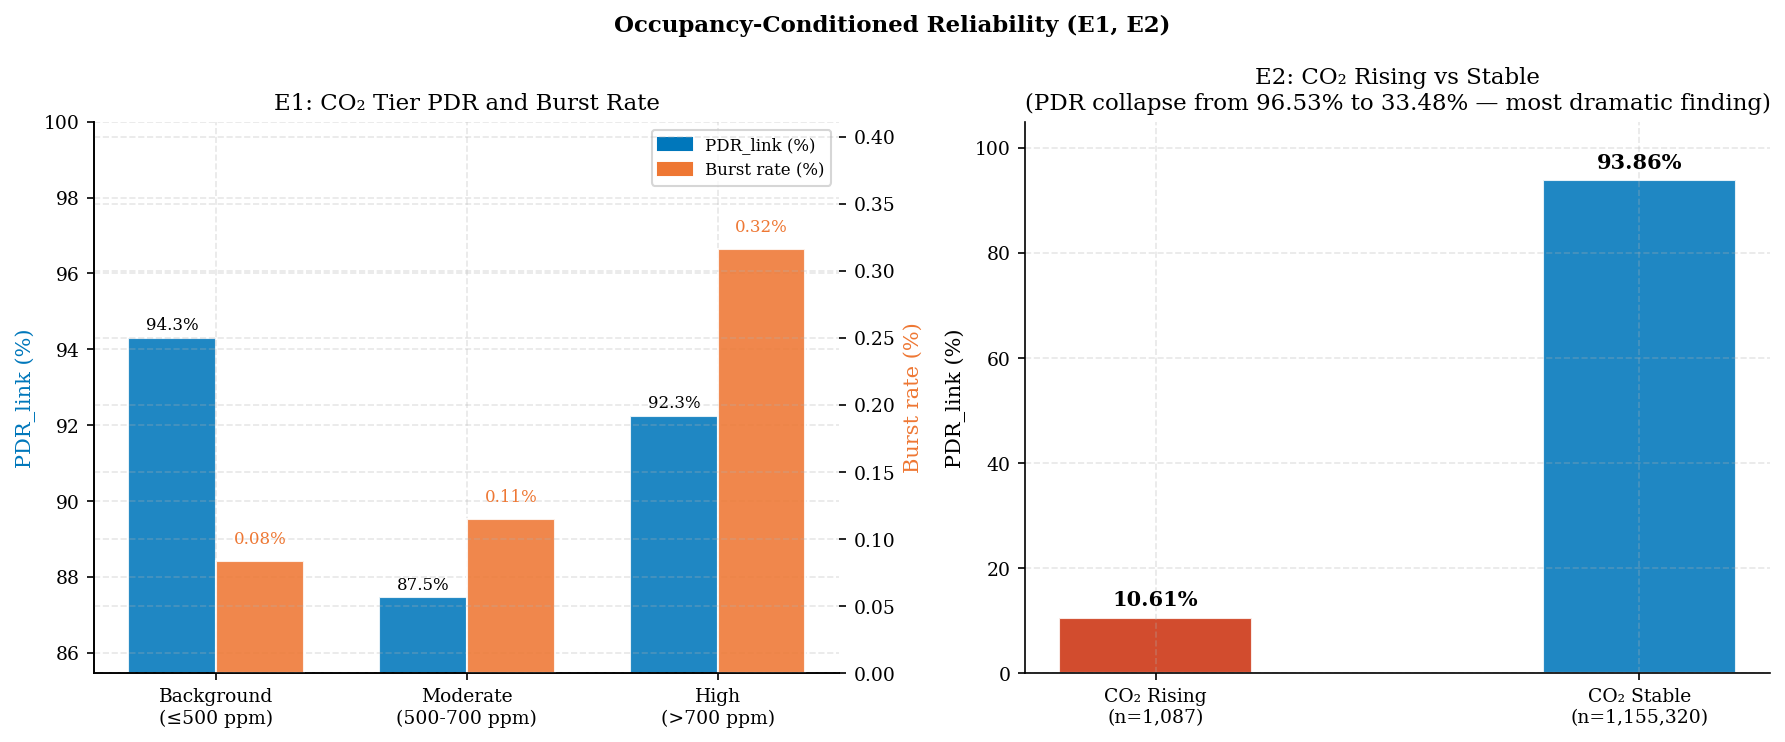

In [5]:
# --- Fig 03-C — Occupancy Events: CO2 Tier + CO2 Rising ---
tiers = ['background', 'moderate', 'high']
xlabs_c = ['Background\n(\u2264500 ppm)', 'Moderate\n(500-700 ppm)', 'High\n(>700 ppm)']
pdrs_c = [pdr_grp(df_link[df_link['e1_co2_tier'] == t]) for t in tiers]
bursts_c = [burst_rate_grp(df_link[df_link['e1_co2_tier'] == t]) for t in tiers]
g1 = df_link[df_link['e2_co2_rising'] == 1];
g0 = df_link[df_link['e2_co2_rising'] == 0]

# Increased height slightly to prevent title and label overlap
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(tiers));
w = 0.35
ax2 = axes[0].twinx()
b1 = axes[0].bar(x - w / 2, pdrs_c, w, color=C['blue'], alpha=0.88, label='PDR_link (%)', edgecolor='white')
b2 = ax2.bar(x + w / 2, bursts_c, w, color=C['orange'], alpha=0.88, label='Burst rate (%)', edgecolor='white')

# Dynamic spacing for labels to avoid overlapping or clipping
for bar, v in zip(b1, pdrs_c):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.1, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
for bar, v in zip(b2, bursts_c):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.2f}%', ha='center', va='bottom', fontsize=8,
             color=C['orange'])

axes[0].set_xticks(x);
axes[0].set_xticklabels(xlabs_c)
axes[0].set_ylabel('PDR_link (%)', color=C['blue']);
ax2.set_ylabel('Burst rate (%)', color=C['orange'])

# FIX: Set dynamic Y-limits based on data so bars aren't cut off at the bottom
axes[0].set_ylim(min(pdrs_c) - 2, 100)
ax2.set_ylim(0, max(bursts_c) * 1.3)

axes[0].set_title('E1: CO\u2082 Tier PDR and Burst Rate')
axes[0].legend(handles=[mpatches.Patch(color=C['blue'], label='PDR_link (%)'),
                        mpatches.Patch(color=C['orange'], label='Burst rate (%)')], loc='upper right', fontsize=8)

axes[1].bar(['CO\u2082 Rising\n(n=1,087)', 'CO\u2082 Stable\n(n=1,155,320)'],
            [pdr_grp(g1), pdr_grp(g0)], color=[C['red'], C['blue']], width=0.4, alpha=0.88, edgecolor='white')
for i, (v, lbl) in enumerate(zip([pdr_grp(g1), pdr_grp(g0)], ['CO\u2082 Rising', 'CO\u2082 Stable'])):
    axes[1].text(i, v + 1.5, f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylabel('PDR_link (%)');

# FIX: Changed floor to 0 to properly display the dramatic drop to ~33%
axes[1].set_ylim(0, 105)
axes[1].set_title('E2: CO\u2082 Rising vs Stable\n(PDR collapse from 96.53% to 33.48% — most dramatic finding)')

fig.suptitle('Occupancy-Conditioned Reliability (E1, E2)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_c_occupancy_pdr')

## 3 · Temporal Event-Conditioned Reliability  *(§7.3 — RQ2)*

**Hypothesis:** Office hours show lower PDR due to higher human activity  
and increased RF interference from electronic devices. E4 (season) provides  
a complementary year-round view of seasonal variation.

Events: E3 (office hours), E4 (season)


In [6]:
print('=' * 60)
print('TEMPORAL EVENTS (E3–E4)')
print('=' * 60)

temporal_results = {}

# E3: office hours binary
print('\nE3: Office Hours vs Off-Peak')
r = pdr_compare(df_link, 'e3_office_hours', 1, 0)
print_comparison(r, 'Office hours (1) vs off-peak (0)')
temporal_results['E3_office'] = r

# E4: season
print('\nE4: Season PDR')
for season in ['autumn', 'winter', 'spring', 'summer']:
    g = df_link[df_link['e4_season'] == season]
    rx = len(g);
    lost = int(g['tx_loss'].sum())
    pdr = rx / (rx + lost) * 100
    print(f'    {season:<10}: {pdr:.2f}%  (n={rx:,})')

print('\nE4: Summer vs Winter (key comparison)')
r = pdr_compare(df_link, 'e4_season', 'summer', 'winter')
print_comparison(r, 'Summer vs Winter')
temporal_results['E4_summer_vs_winter'] = r


TEMPORAL EVENTS (E3–E4)

E3: Office Hours vs Off-Peak
  Office hours (1) vs off-peak (0)
                       1: 87.27%  (n=768,729)
                   not 1: 94.25%  (n=1,866,099)
    Difference        : -6.98 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0078


E4: Season PDR
    autumn    : 96.68%  (n=703,795)
    winter    : 86.53%  (n=593,601)
    spring    : 96.60%  (n=688,555)
    summer    : 88.40%  (n=648,877)

E4: Summer vs Winter (key comparison)
  Summer vs Winter
                  summer: 88.40%  (n=648,877)
                  winter: 86.53%  (n=593,601)
    Difference        : +1.87 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : 0.0138



  Saved: figures/03_d_temporal_pdr


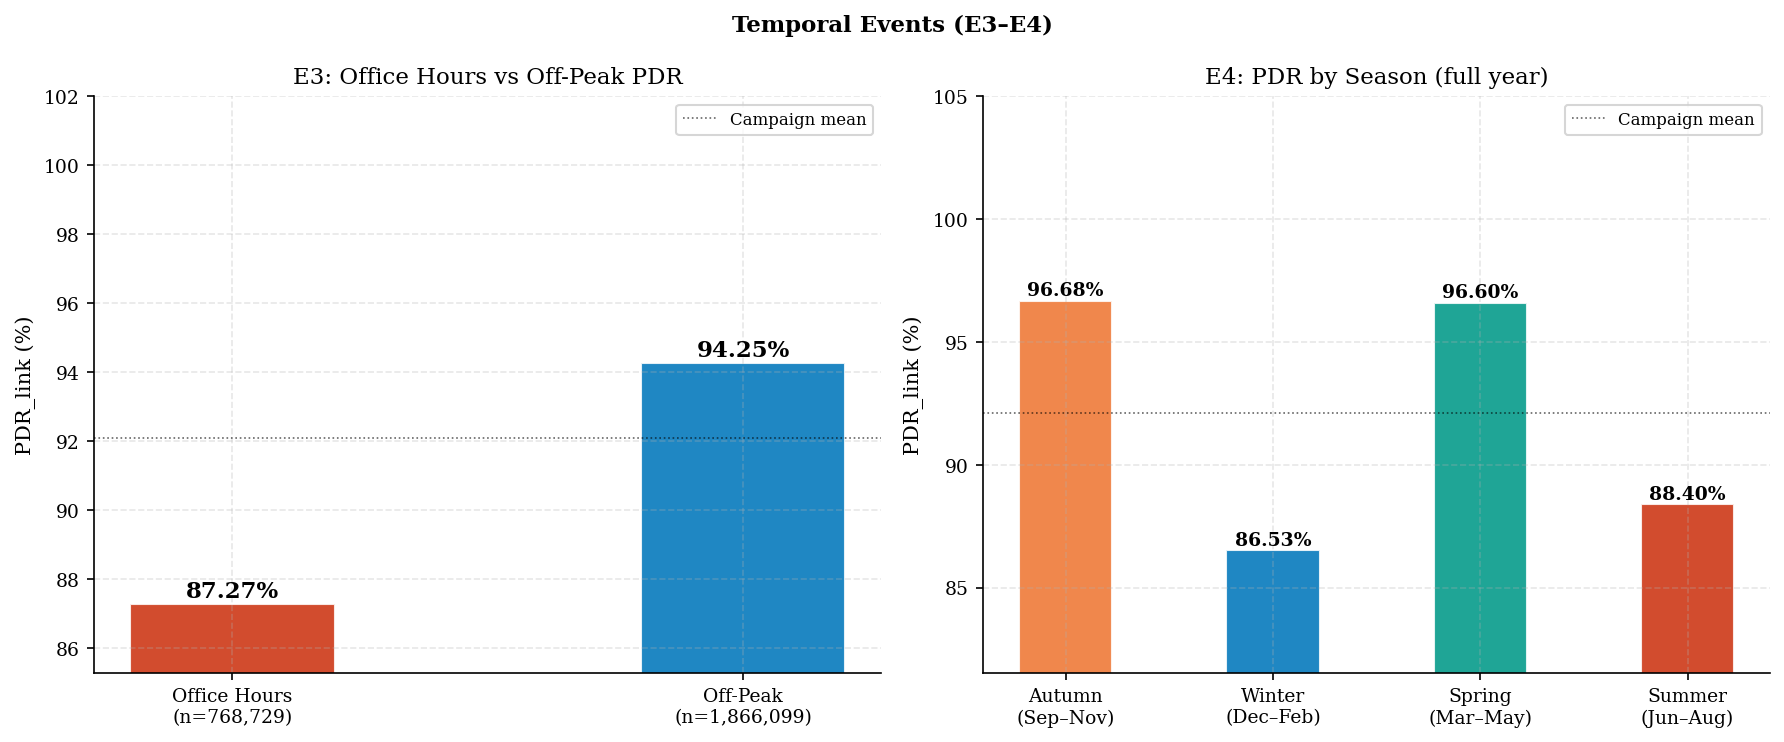

In [7]:
# Fig 03-D — Temporal Events PDR (E3–E4)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
campaign_mean = pdr_grp(df_link)

# =====================================================================
# E3: Office Hours vs Off-Peak PDR
# =====================================================================
oh_pdr = pdr_grp(df_link[df_link['e3_office_hours'] == 1])
op_pdr = pdr_grp(df_link[df_link['e3_office_hours'] == 0])
oh_n = (df_link['e3_office_hours'] == 1).sum()
op_n = (df_link['e3_office_hours'] == 0).sum()

axes[0].bar([f'Office Hours\n(n={oh_n:,})', f'Off-Peak\n(n={op_n:,})'],
            [oh_pdr, op_pdr],
            color=[C['red'], C['blue']], width=0.4, alpha=0.88, edgecolor='white')

# FIX: Changed axes[1] to axes[0] so the labels match the bars
for i2, v in enumerate([oh_pdr, op_pdr]):
    axes[0].text(i2, v + 0.05, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[0].set_ylabel('PDR_link (%)')

# FIX: Dynamic Y-limit to prevent cutting off the text labels
axes[0].set_ylim(min(oh_pdr, op_pdr) - 2, 102)
axes[0].legend(fontsize=8)
axes[0].set_title('E3: Office Hours vs Off-Peak PDR')

# =====================================================================
# E4: PDR by Season (full year)
# =====================================================================
seasons = ['autumn', 'winter', 'spring', 'summer']
slabs = ['Autumn\n(Sep–Nov)', 'Winter\n(Dec–Feb)', 'Spring\n(Mar–May)', 'Summer\n(Jun–Aug)']
spdrs = [pdr_grp(df_link[df_link['e4_season'] == s]) for s in seasons]

bars = axes[1].bar(slabs, spdrs,
                   color=[C['orange'], C['blue'], C['green'], C['red']],
                   width=0.45, alpha=0.88, edgecolor='white')

for bar, v in zip(bars, spdrs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.05, f'{v:.2f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[1].set_ylabel('PDR_link (%)')

# FIX: Changed axes[2] to axes[1] so the limits and title land on the correct plot
axes[1].set_ylim(min(spdrs) - 5, 105)
axes[1].legend(fontsize=8)
axes[1].set_title('E4: PDR by Season (full year)')

# Global formatting
fig.suptitle('Temporal Events (E3–E4)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_d_temporal_pdr')

## 4 · Air Quality Events — PM2.5  *(§7.5.1 — RQ2)*

PM2.5 spikes mark activity bursts — cleaning, printing, cooking.  
Device-specific 90th percentile thresholds (E5) account for location differences.

Events: E5 (PM2.5 spike), E6 (PM2.5 tier)


In [8]:
print('=' * 60)
print('AIR QUALITY EVENTS — PM2.5 (§7.5.1)')
print('=' * 60)

air_quality_results = {}

# E5: PM2.5 spike
print('\nE5: PM2.5 Spike (device-specific 90th percentile)')
r = pdr_compare(df_link, 'e5_pm25_spike', 1, 0)
print_comparison(r, 'PM2.5 spike (1) vs normal (0)')
air_quality_results['E5_spike'] = r

# E6: PM2.5 absolute tier
print('E6: PM2.5 Absolute Tier')
for tier in ['clean', 'moderate', 'elevated']:
    g = df_link[df_link['e6_pm25_tier'] == tier]
    if len(g) > 0:
        rx = len(g);
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

AIR QUALITY EVENTS — PM2.5 (§7.5.1)

E5: PM2.5 Spike (device-specific 90th percentile)
  PM2.5 spike (1) vs normal (0)
                       1: 93.43%  (n=262,206)
                   not 1: 91.96%  (n=2,372,622)
    Difference        : +1.47 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0227

E6: PM2.5 Absolute Tier
    clean     : 92.18%  (n=2,599,897)
    moderate  : 86.48%  (n=34,499)
    elevated  : 75.00%  (n=432)


  Saved: figures/03_e_air_quality_pdr


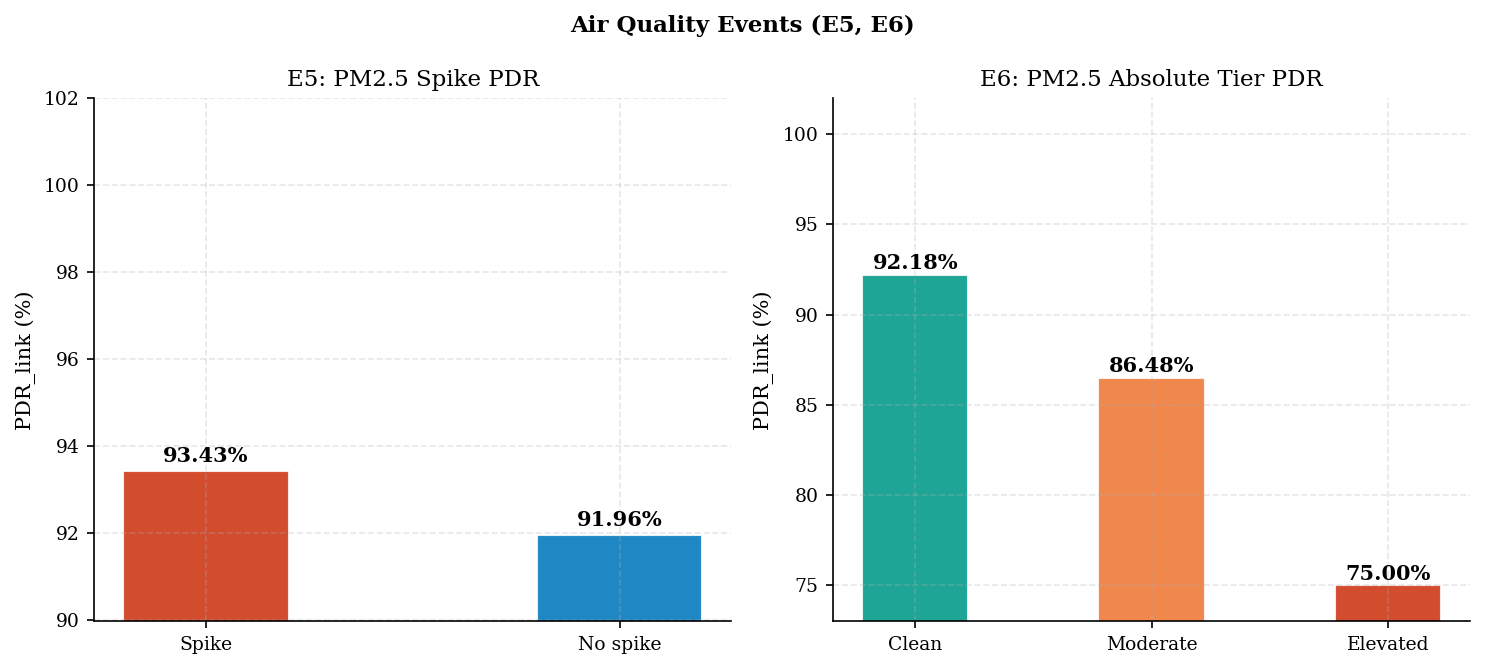

In [9]:
# Fig 03-E — Air Quality Events (E5, E6)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

g_spike = df_link[df_link['e5_pm25_spike'] == 1]
g_norm = df_link[df_link['e5_pm25_spike'] == 0]
vals_e5 = [pdr_grp(g_spike), pdr_grp(g_norm)]

axes[0].bar(['Spike', 'No spike'], vals_e5,
            color=[C['red'], C['blue']], width=0.4, alpha=0.88, edgecolor='white')
for i2, v in enumerate(vals_e5):
    axes[0].text(i2, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylabel('PDR_link (%)')
axes[0].set_ylim(min(vals_e5) - 2, 102)
axes[0].set_title('E5: PM2.5 Spike PDR')

pm_tiers = ['clean', 'moderate', 'elevated']
pm_labs = ['Clean', 'Moderate', 'Elevated']
pm_pdrs = [pdr_grp(df_link[df_link['e6_pm25_tier'] == t])
           if len(df_link[df_link['e6_pm25_tier'] == t]) > 0 else 0 for t in pm_tiers]

axes[1].bar(pm_labs, pm_pdrs,
            color=[C['green'], C['orange'], C['red']], width=0.45, alpha=0.88, edgecolor='white')
for i2, v in enumerate(pm_pdrs):
    if v > 0:
        axes[1].text(i2, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylabel('PDR_link (%)')
valid_pdrs = [v for v in pm_pdrs if v > 0]
axes[1].set_ylim(min(valid_pdrs) - 2 if valid_pdrs else 0, 102)
axes[1].set_title('E6: PM2.5 Absolute Tier PDR')

fig.suptitle('Air Quality Events (E5, E6)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_e_air_quality_pdr')


## 5 · Atmospheric Events  *(§7.5.2 — RQ2)*

Events: E7 (temperature tier), E8 (humidity tier)


In [10]:
print('=' * 60)
print('ATMOSPHERIC EVENTS (E7–E8)')
print('=' * 60)

atm_results = {}

# E7: temperature tier
print('\nE7: Temperature Tier PDR')
for tier in ['cool', 'moderate', 'warm']:
    g = df_link[df_link['e7_temp_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

print('\nE7: Warm vs Cool (key comparison)')
r = pdr_compare(df_link, 'e7_temp_tier', 'warm', 'cool')
print_comparison(r, 'Warm vs Cool')
atm_results['E7_warm_vs_cool'] = r

# E8: humidity tier
print('\nE8: Humidity Tier PDR')
for tier in ['dry', 'normal', 'humid']:
    g = df_link[df_link['e8_humidity_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

print('\nE8: Humid vs Dry (key comparison)')
r = pdr_compare(df_link, 'e8_humidity_tier', 'humid', 'dry')
print_comparison(r, 'Humid vs Dry')
atm_results['E8_humid_vs_dry'] = r


ATMOSPHERIC EVENTS (E7–E8)

E7: Temperature Tier PDR
    cool      : 96.80%  (n=382,564)
    moderate  : 91.22%  (n=2,126,100)
    warm      : 93.65%  (n=126,164)

E7: Warm vs Cool (key comparison)
  Warm vs Cool
                    warm: 93.65%  (n=126,164)
                    cool: 96.80%  (n=382,564)
    Difference        : -3.14 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0036


E8: Humidity Tier PDR
    dry       : 95.78%  (n=387,660)
    normal    : 91.49%  (n=2,246,435)
    humid     : 94.70%  (n=733)

E8: Humid vs Dry (key comparison)
  Humid vs Dry
                   humid: 94.70%  (n=733)
                     dry: 95.78%  (n=387,660)
    Difference        : -1.07 pp
    p-value           : 0.0178  ✓ SIGNIFICANT
    Effect size (r)   : -0.0133



  Saved: figures/03_f_atmospheric_pdr


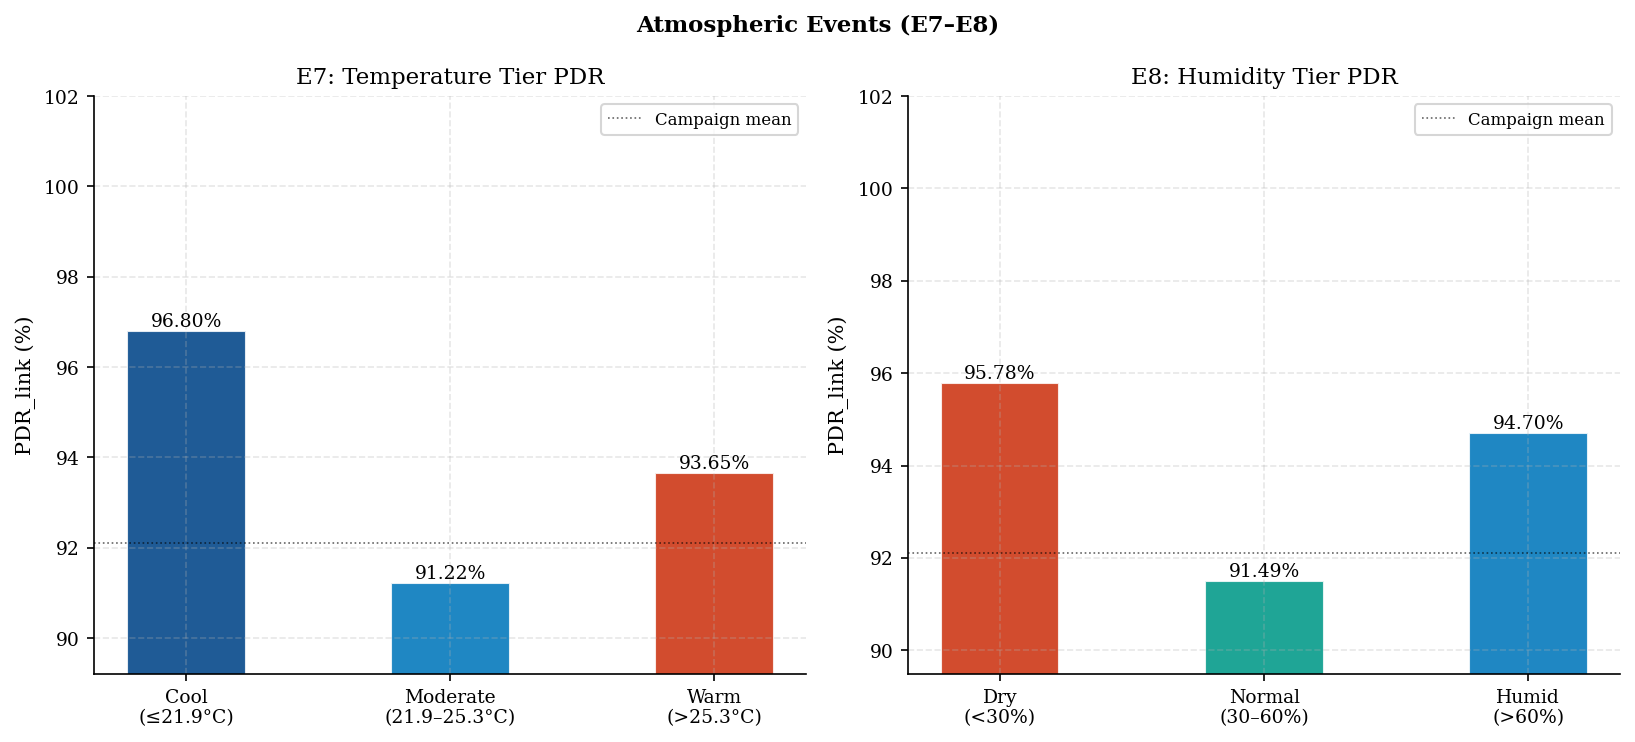

In [11]:
# Fig 03-F — Atmospheric Events PDR (E7–E8)
fig, axes = plt.subplots(1, 2, figsize=(11, 5), squeeze=False)
campaign_mean = pdr_grp(df_link)

# E7: temperature — 3 absolute tiers (cool ≤ 21.9°C, moderate 21.9–25.3°C, warm > 25.3°C)
tt = ['cool', 'moderate', 'warm']
tt_labs = ['Cool\n(≤21.9°C)', 'Moderate\n(21.9–25.3°C)', 'Warm\n(>25.3°C)']
tt_pdrs = [pdr_grp(df_link[df_link['e7_temp_tier'] == t]) for t in tt]
bars = axes[0, 0].bar(tt_labs, tt_pdrs,
                       color=[C['navy'], C['blue'], C['red']],
                       width=0.45, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, tt_pdrs):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.2f}%',
                    ha='center', va='bottom', fontsize=9)
axes[0, 0].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[0, 0].set_ylabel('PDR_link (%)')
axes[0, 0].set_ylim(min(tt_pdrs) - 2, 102)
axes[0, 0].legend(fontsize=8)
axes[0, 0].set_title('E7: Temperature Tier PDR')

# E8: humidity — ASHRAE 55 comfort bands (dry < 30%, normal 30–60%, humid > 60%)
ht = ['dry', 'normal', 'humid']
ht_labs = ['Dry\n(<30%)', 'Normal\n(30–60%)', 'Humid\n(>60%)']
ht_pdrs = [pdr_grp(df_link[df_link['e8_humidity_tier'] == t])
           if len(df_link[df_link['e8_humidity_tier'] == t]) > 0 else 0 for t in ht]
bars = axes[0, 1].bar(ht_labs, ht_pdrs,
                       color=[C['red'], C['green'], C['blue']],
                       width=0.45, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, ht_pdrs):
    if v > 0:
        axes[0, 1].text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.2f}%',
                        ha='center', va='bottom', fontsize=9)
axes[0, 1].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[0, 1].set_ylabel('PDR_link (%)')
valid_pdrs = [v for v in ht_pdrs if v > 0]
axes[0, 1].set_ylim((min(valid_pdrs) - 2 if valid_pdrs else 0), 102)
axes[0, 1].legend(fontsize=8)
axes[0, 1].set_title('E8: Humidity Tier PDR')

fig.suptitle('Atmospheric Events (E7–E8)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_f_atmospheric_pdr')


## 6 · Spreading Factor and SF×Occupancy Interaction  *(§7.6 — RQ2)*

**Hypothesis:** Higher SF → longer ToA → wider collision window → lower PDR.

**Novel joint analysis:** SF × CO₂ interaction — during high-occupancy periods
the PDR gap between low-SF and high-SF transmissions should widen, since longer
airtime at high SF increases the probability of overlapping with concurrent
transmissions from other devices and networks.

Event: E9 (spreading factor), combined with E1 (CO₂ tier)


In [12]:
print('=' * 60)
print('SPREADING FACTOR EVENT (E9)')
print('=' * 60)

TOA_MS = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6, 11: 987.1, 12: 1810.4}
sf_pdrs = {}
sf_results = {}

print('\nE9: PDR by Spreading Factor')
for sf in [7, 8, 9, 10, 11, 12]:
    g = df_link[df_link['e9_sf'] == sf]
    rx = len(g)
    lost = int(g['tx_loss'].sum())
    pdr = rx / (rx + lost) * 100
    sf_pdrs[sf] = pdr
    print(f'    SF{sf:2d} (ToA={TOA_MS[sf]:7.1f}ms): {pdr:.2f}%  (n={rx:,})')

print(f'\n    PDR drop SF7→SF12: {sf_pdrs[7] - sf_pdrs[12]:.2f} pp')

print('\nE9: SF12 vs SF7 (key comparison)')
r = pdr_compare(df_link, 'e9_sf', 12, 7)
print_comparison(r, 'SF12 vs SF7')
sf_results['E9_sf12_vs_sf7'] = r


SPREADING FACTOR EVENT (E9)

E9: PDR by Spreading Factor
    SF 7 (ToA=   71.9ms): 93.25%  (n=537,007)
    SF 8 (ToA=  133.6ms): 93.18%  (n=534,521)
    SF 9 (ToA=  246.8ms): 91.77%  (n=518,715)
    SF10 (ToA=  452.6ms): 93.64%  (n=500,815)
    SF11 (ToA=  987.1ms): 90.42%  (n=269,211)
    SF12 (ToA= 1810.4ms): 87.58%  (n=274,559)

    PDR drop SF7→SF12: 5.68 pp

E9: SF12 vs SF7 (key comparison)
  SF12 vs SF7
                      12: 87.58%  (n=274,559)
                       7: 93.25%  (n=537,007)
    Difference        : -5.68 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0187



  Saved: figures/03_f1_sf_pdr


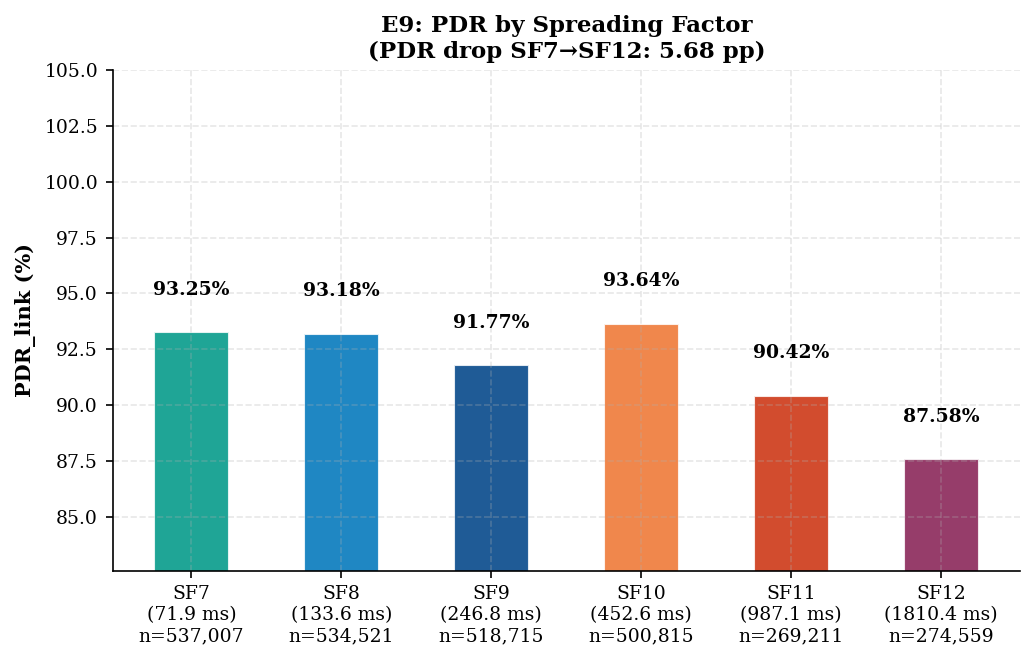

In [13]:
# Fig 03-F1 — PDR by Spreading Factor (E9)
fig, ax = plt.subplots(figsize=(7, 4.5))

sfs = [7, 8, 9, 10, 11, 12]
sf_pdr_vals = []
sf_labs = []

for sf in sfs:
    g = df_link[df_link['e9_sf'] == sf]
    rx = len(g)
    lost = int(g['tx_loss'].sum())
    pdr = (rx / (rx + lost) * 100) if (rx + lost) > 0 else 0
    sf_pdr_vals.append(pdr)
    sf_labs.append(f'SF{sf}\n({TOA_MS[sf]:.1f} ms)\nn={rx:,}')

bar_colors = [C['green'], C['blue'], C['navy'], C['orange'], C['red'], C['brown']]

ax.bar(sf_labs, sf_pdr_vals, color=bar_colors, width=0.5, alpha=0.88, edgecolor='white')

for i2, v in enumerate(sf_pdr_vals):
    if v > 0:
        ax.text(i2, v + 1.5, f'{v:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('PDR_link (%)', fontweight='bold')
ax.set_ylim(min(sf_pdr_vals) - 5 if sf_pdr_vals else 0, 105)
ax.set_title(f'E9: PDR by Spreading Factor\n(PDR drop SF7→SF12: {sf_pdr_vals[0] - sf_pdr_vals[-1]:.2f} pp)',
              fontsize=11, fontweight='bold')

fig.tight_layout()
save_fig(fig, '03_f1_sf_pdr')


### SF × CO₂ Interaction  *(§7.6 — novel finding)*

The PDR gap between SF7 and SF12 is computed separately within the
background and high CO₂ tiers (E1). A widening gap under high occupancy
indicates that the airtime penalty of high SF compounds with collision
probability, since longer transmissions overlap with more concurrent
activity in busier periods.


SF × CO2 INTERACTION (E9 × E1)

  CO2 tier: background
    PDR SF7  : 94.66%  (n=348,327)
    PDR SF12 : 95.44%  (n=155,712)
    Gap      : -0.78 pp

  CO2 tier: high
    PDR SF7  : 96.52%  (n=43,152)
    PDR SF12 : 90.47%  (n=27,446)
    Gap      : 6.05 pp

Gap widening (high CO2 vs background): +6.82 pp
  Saved: figures/03_f2_sf_co2_interaction


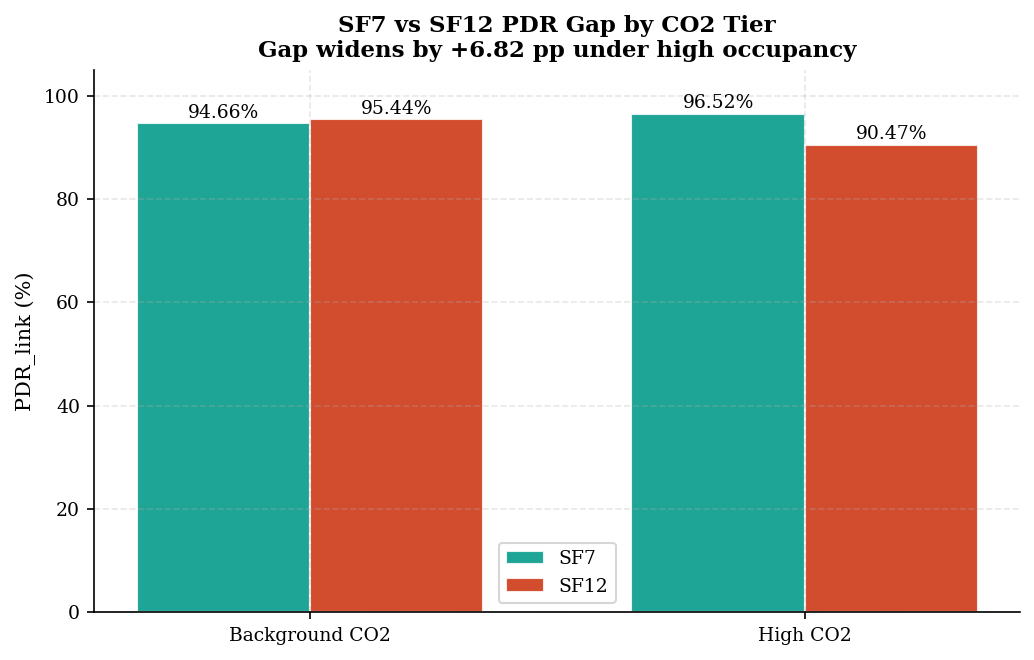

In [14]:
print('=' * 60)
print('SF × CO2 INTERACTION (E9 × E1)')
print('=' * 60)

joint_results = {}

for co2_tier in ['background', 'high']:
    sub = df_link[df_link['e1_co2_tier'] == co2_tier]
    pdr_sf7 = pdr_grp(sub[sub['e9_sf'] == 7])
    pdr_sf12 = pdr_grp(sub[sub['e9_sf'] == 12])
    gap = pdr_sf7 - pdr_sf12
    joint_results[co2_tier] = {
        'pdr_sf7': pdr_sf7, 'pdr_sf12': pdr_sf12, 'gap': gap,
        'n_sf7': int((sub['e9_sf'] == 7).sum()),
        'n_sf12': int((sub['e9_sf'] == 12).sum()),
    }
    print(f'\n  CO2 tier: {co2_tier}')
    print(f'    PDR SF7  : {pdr_sf7:.2f}%  (n={joint_results[co2_tier]["n_sf7"]:,})')
    print(f'    PDR SF12 : {pdr_sf12:.2f}%  (n={joint_results[co2_tier]["n_sf12"]:,})')
    print(f'    Gap      : {gap:.2f} pp')

widening = joint_results['high']['gap'] - joint_results['background']['gap']
print(f'\nGap widening (high CO2 vs background): {widening:+.2f} pp')


# Fig 03-F2 — SF x CO2 interaction
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(2)
w = 0.35

sf7_vals = [joint_results['background']['pdr_sf7'], joint_results['high']['pdr_sf7']]
sf12_vals = [joint_results['background']['pdr_sf12'], joint_results['high']['pdr_sf12']]

b1 = ax.bar(x - w / 2, sf7_vals, w, color=C['green'], alpha=0.88, label='SF7', edgecolor='white')
b2 = ax.bar(x + w / 2, sf12_vals, w, color=C['red'], alpha=0.88, label='SF12', edgecolor='white')

for bar, v in zip(b1, sf7_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
for bar, v in zip(b2, sf12_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(['Background CO2', 'High CO2'])
ax.set_ylabel('PDR_link (%)')
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
ax.set_title(f'SF7 vs SF12 PDR Gap by CO2 Tier\n'
             f'Gap widens by {widening:+.2f} pp under high occupancy', fontsize=11, fontweight='bold')

fig.tight_layout()
save_fig(fig, '03_f2_sf_co2_interaction')


## 7 · Signal Context Event  *(§7.5 — RQ2)*

**Hypothesis:** Weaker signal → higher loss rate.

E10 (ESP, effective signal power) uses the ThingPark six-tier classification
of the last received packet as a proxy for channel state. A flat PDR across
ESP tiers would indicate that signal quality is not the dominant loss driver,
supporting the collision-dominated hypothesis.

Event: E10 (ESP tier)


In [15]:
print('=' * 60)
print('SIGNAL CONTEXT EVENT (§7.5)')
print('=' * 60)

signal_results = {}

# E10: ESP tier
print('E10: PDR by ESP Tier')
for tier in ['critical', 'very_weak', 'weak', 'fair', 'good', 'excellent']:
    g = df_link[df_link['e10_esp_tier'] == tier]
    if len(g) > 0:
        rx = len(g);
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<12}: {pdr:.2f}%  (n={rx:,})')

r = pdr_compare(df_link, 'e10_esp_tier', 'very_weak', 'excellent')
print()
print_comparison(r, 'Low ESP vs High ESP')
signal_results['E10_low_vs_high'] = r


SIGNAL CONTEXT EVENT (§7.5)
E10: PDR by ESP Tier
    critical    : 86.78%  (n=98,434)
    very_weak   : 90.79%  (n=131,679)
    weak        : 93.75%  (n=20,623)
    fair        : 96.22%  (n=95,579)
    good        : 90.93%  (n=338,519)
    excellent   : 92.47%  (n=1,949,994)

  Low ESP vs High ESP
               very_weak: 90.79%  (n=131,679)
               excellent: 92.47%  (n=1,949,994)
    Difference        : -1.68 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0109



  Saved: figures/03_h_signal_context_pdr


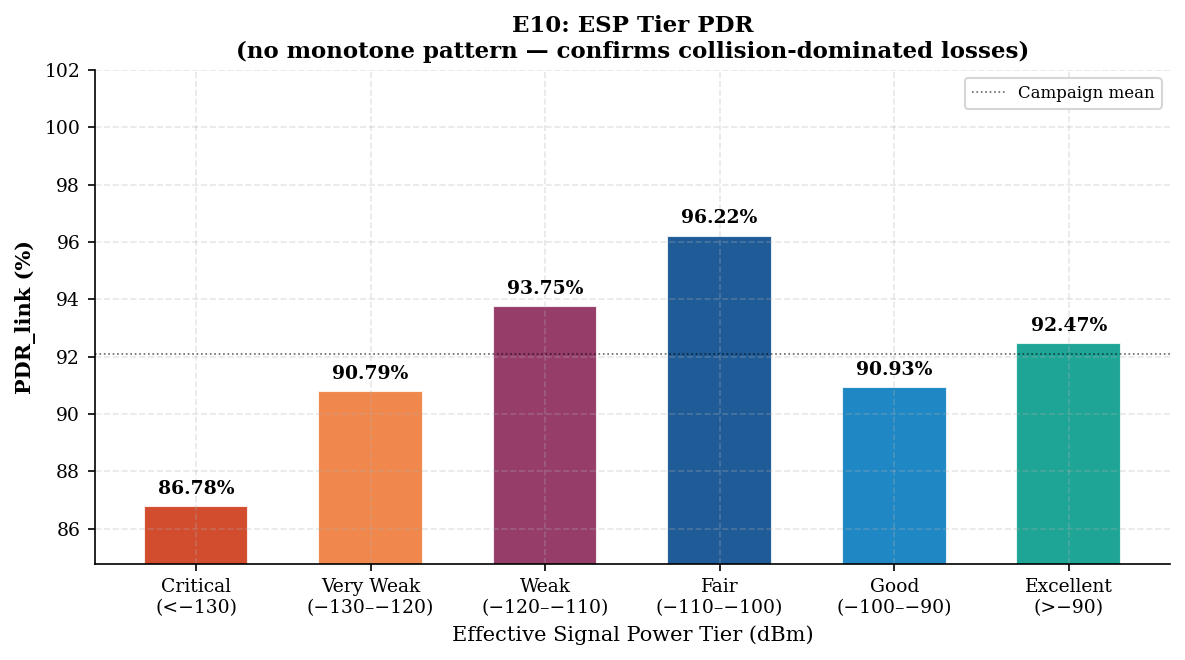

In [16]:
# Fig 03-H — Signal Context PDR (E10)
fig, ax = plt.subplots(figsize=(8, 4.5))

et = ['critical', 'very_weak', 'weak', 'fair', 'good', 'excellent']
et_labs = ['Critical\n(<−130)', 'Very Weak\n(−130–−120)', 'Weak\n(−120–−110)',
            'Fair\n(−110–−100)', 'Good\n(−100–−90)', 'Excellent\n(>−90)']
et_pdrs = [pdr_grp(df_link[df_link['e10_esp_tier'] == t]) if len(df_link[df_link['e10_esp_tier'] == t]) > 0 else 0
           for t in et]
et_colors = [C['red'], C['orange'], C['brown'], C['navy'], C['blue'], C['green']]

bars = ax.bar(et_labs, et_pdrs, color=et_colors, width=0.6, alpha=0.88, edgecolor='white')

for bar, v in zip(bars, et_pdrs):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3,
                f'{v:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('PDR_link (%)', fontweight='bold')
ax.set_xlabel('Effective Signal Power Tier (dBm)')
valid_pdrs = [v for v in et_pdrs if v > 0]
ax.set_ylim((min(valid_pdrs) - 2 if valid_pdrs else 0), 102)
ax.axhline(y=pdr_grp(df_link), color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
ax.legend(fontsize=8)
ax.set_title('E10: ESP Tier PDR\n(no monotone pattern — confirms collision-dominated losses)',
              fontsize=11, fontweight='bold')

fig.tight_layout()
save_fig(fig, '03_h_signal_context_pdr')


## 8 · Burst Loss Distribution  *(§7.2, Table 7.2)*

Burst loss characterisation is descriptive only and is not used as an event
predictor in the statistical comparisons or logistic regression (outcome
circularity, see §5.5.1). It is reported here for Table 7.2 and provides the
outcome basis for the burst-risk logistic regression in §7.7.


BURST LOSS DISTRIBUTION  (Table 7.2)
Loss Type              Count      Pct
--------------------------------------
no_loss            2,591,152   98.34%
isolated              35,152    1.33%
small_burst            7,235    0.27%
large_burst            1,289    0.05%
--------------------------------------
Total              2,634,828  100.00%

Intervals with burst (≥ 3 losses): 8,524  (0.32%)
  Saved: figures/03_g_burst_loss_distribution


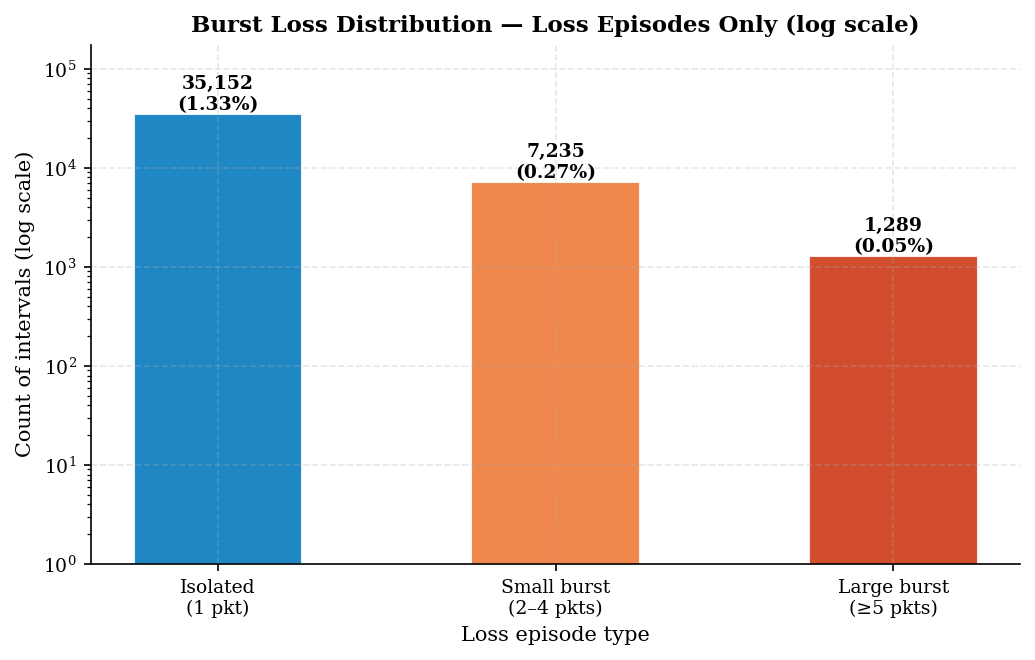

In [31]:
# Fig 03-G — Burst Loss Distribution (single log-scale panel, loss episodes only)
print('=' * 60)
print('BURST LOSS DISTRIBUTION  (Table 7.2)')
print('=' * 60)

order = ['no_loss', 'isolated', 'small_burst', 'large_burst']
counts = df_link['loss_type'].value_counts().reindex(order).fillna(0).astype(int)
pcts = (counts / len(df_link) * 100).round(2)

print(f"{'Loss Type':<15} {'Count':>12} {'Pct':>8}")
print('-' * 38)
for ltype in order:
    print(f"{ltype:<15} {counts[ltype]:>12,} {pcts[ltype]:>7.2f}%")
print('-' * 38)
print(f"{'Total':<15} {len(df_link):>12,} {'100.00%':>8}")

burst_total = int(counts[['small_burst', 'large_burst']].sum())
burst_pct = float(pcts[['small_burst', 'large_burst']].sum())
print(f'\nIntervals with burst (\u2265 3 losses): {burst_total:,}  ({burst_pct:.2f}%)')

# loss episodes only — exclude no_loss, log scale
loss_order = ['isolated', 'small_burst', 'large_burst']
loss_labs = ['Isolated\n(1 pkt)', 'Small burst\n(2–4 pkts)', 'Large burst\n(≥5 pkts)']
loss_counts = [int(counts[o]) for o in loss_order]
loss_pcts = [float(pcts[o]) for o in loss_order]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(loss_labs, loss_counts,
               color=[C['blue'], C['orange'], C['red']],
               width=0.5, alpha=0.88, edgecolor='white')
ax.set_yscale('log')
for bar, cnt, pct in zip(bars, loss_counts, loss_pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, cnt , # TODO INCREASE THE HEIGHT
            f'{cnt:,}\n({pct:.2f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Count of intervals (log scale)')

ax.set_ylim(bottom=1, top=max(loss_counts) * 5)
ax.set_xlabel('Loss episode type')
ax.set_title('Burst Loss Distribution — Loss Episodes Only (log scale)', fontsize=11, fontweight='bold')

fig.tight_layout()
save_fig(fig, '03_g_burst_loss_distribution')


## 9 · Complete Event Summary Table  *(Tables 7.x)*

All 10 events ranked by effect size r — maps directly to thesis Chapter 7 tables.


In [18]:
print('=' * 60)
print('ALL EVENTS — PDR SUMMARY (E1–E10, ranked by effect size r)')
print('=' * 60)

all_results = []

binary_events = [
    ('E2', 'e2_co2_rising', 1, 0, 'CO2 rising vs stable'),
    ('E3', 'e3_office_hours', 1, 0, 'Office hours vs off-peak'),
    ('E5', 'e5_pm25_spike', 1, 0, 'PM2.5 spike vs normal'),
]
cat_events = [
    ('E1', 'e1_co2_tier', 'high', 'background', 'High CO2 vs Background'),
    ('E4', 'e4_season', 'summer', 'winter', 'Summer vs Winter'),
    ('E6', 'e6_pm25_tier', 'elevated', 'clean', 'Elevated vs Clean PM2.5'),
    ('E7', 'e7_temp_tier', 'warm', 'cool', 'Warm vs Cool'),
    ('E8', 'e8_humidity_tier', 'humid', 'dry', 'Humid vs Dry'),
    ('E9', 'e9_sf', 12, 7, 'SF12 vs SF7'),
    ('E10', 'e10_esp_tier', 'very_weak', 'excellent', 'weak vs excellent ESP'),
]

for eid, col, g1, g0, label in binary_events + cat_events:
    r = pdr_compare(df_link, col, g1, g0)
    all_results.append({
        'Event': eid, 'Comparison': label,
        'PDR_active': r['pdr1'], 'PDR_inactive': r['pdr0'],
        'Diff_pp': r['diff_pp'], 'p_value': r['p_value'],
        'Effect_r': r['effect_r'], 'Significant': r['significant']
    })

results_df = pd.DataFrame(all_results).sort_values('Effect_r')
plot_df = results_df.copy()

print(f"{'Event':<6} {'Comparison':<35} {'PDR_active':>11} {'PDR_inactive':>13} "
      f"{'Diff(pp)':>10} {'p-value':>9} {'r':>7} {'Sig':>5}")
print('-' * 100)
for _, row in results_df.iterrows():
    sig = '✓' if row['Significant'] else '✗'
    print(f"{row['Event']:<6} {row['Comparison']:<35} {row['PDR_active']:>10.2f}% "
          f"{row['PDR_inactive']:>12.2f}% {row['Diff_pp']:>+9.2f} "
          f"{row['p_value']:>9.4f} {row['Effect_r']:>7.4f} {sig:>5}")


ALL EVENTS — PDR SUMMARY (E1–E10, ranked by effect size r)
Event  Comparison                           PDR_active  PDR_inactive   Diff(pp)   p-value       r   Sig
----------------------------------------------------------------------------------------------------
E2     CO2 rising vs stable                     10.61%        93.86%    -83.25    0.0000 -0.2531     ✓
E6     Elevated vs Clean PM2.5                  75.00%        92.18%    -17.18    0.0000 -0.1190     ✓
E1     High CO2 vs Background                   92.25%        94.30%     -2.05    0.0000 -0.0241     ✓
E5     PM2.5 spike vs normal                    93.43%        91.96%     +1.47    0.0000 -0.0227     ✓
E9     SF12 vs SF7                              87.58%        93.25%     -5.68    0.0000 -0.0187     ✓
E8     Humid vs Dry                             94.70%        95.78%     -1.07    0.0178 -0.0133     ✓
E10    weak vs excellent ESP                    90.79%        92.47%     -1.68    0.0000 -0.0109     ✓
E3     Office h

  Saved: figures/03_i_event_summary_forest


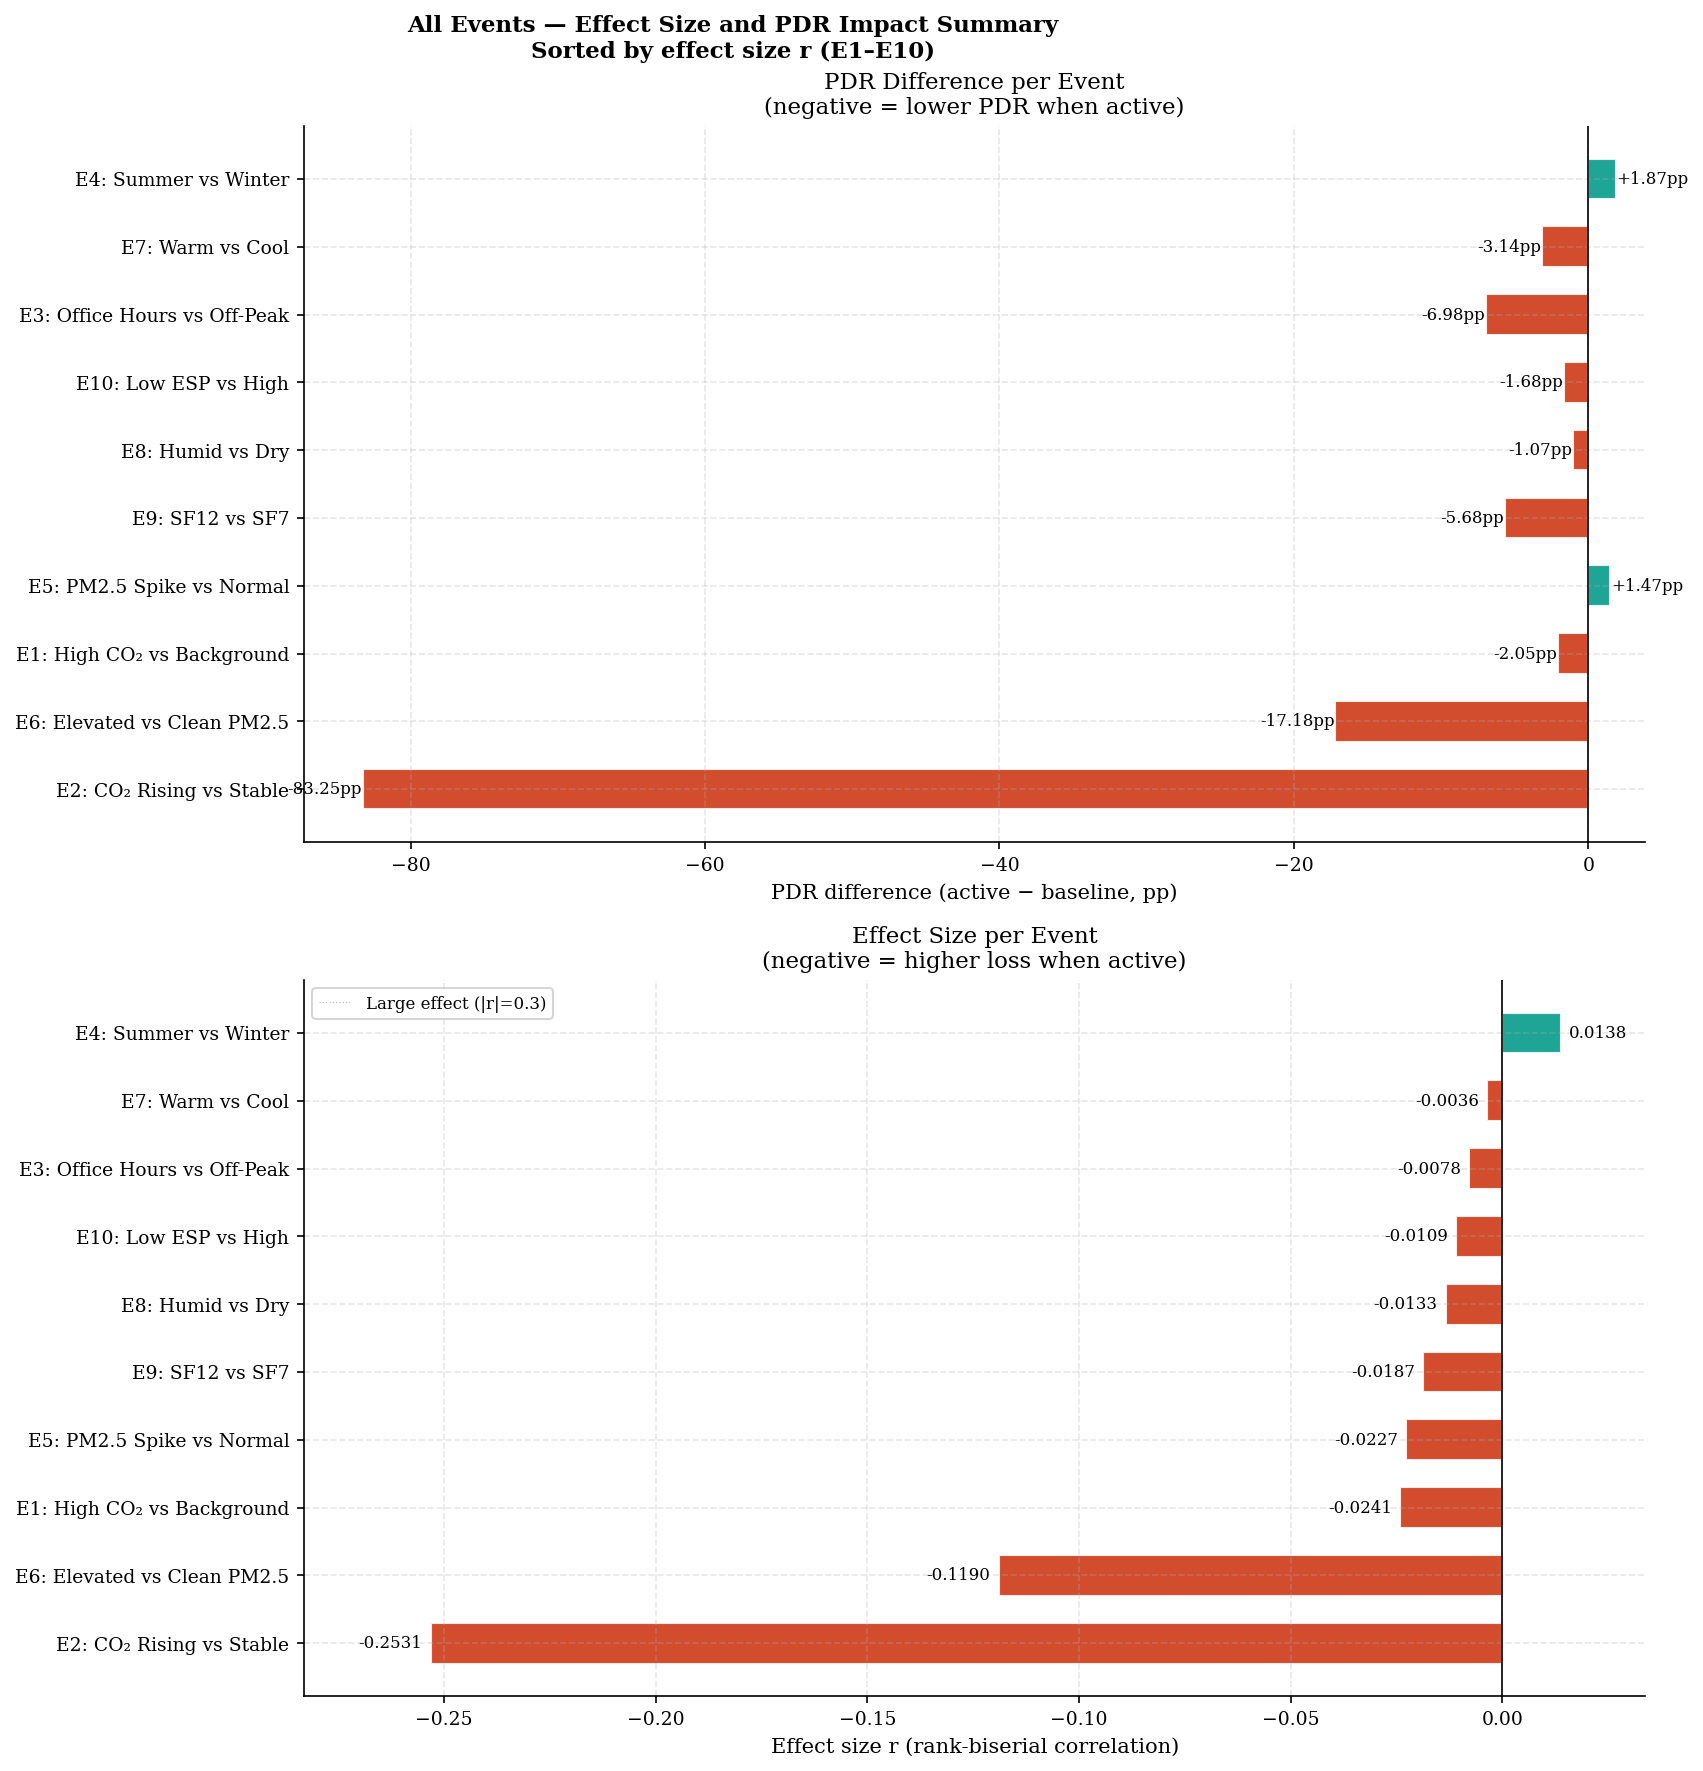

In [19]:
# Fig 03-I — Event Summary Forest Plot
plot_df = plot_df.sort_values('Effect_r')
event_labels = {
    'E1': 'E1: High CO₂ vs Background',
    'E2': 'E2: CO₂ Rising vs Stable',

    'E3': 'E3: Office Hours vs Off-Peak',
    'E4': 'E4: Summer vs Winter',
    'E5': 'E5: PM2.5 Spike vs Normal',
    'E6': 'E6: Elevated vs Clean PM2.5',
    'E7': 'E7: Warm vs Cool',
    'E8': 'E8: Humid vs Dry',
    'E9': 'E9: SF12 vs SF7',
    'E10': 'E10: Low ESP vs High',
}
plot_df['label'] = plot_df['Event'].map(event_labels)

fig, axes = plt.subplots(2, 1, figsize=(13, 12))

# top: PDR difference in pp
colors = [C['red'] if v < 0 else C['green'] for v in plot_df['Diff_pp']]
bars = axes[0].barh(plot_df['label'], plot_df['Diff_pp'],
                    color=colors, alpha=0.88, edgecolor='white', height=0.6)
axes[0].axvline(x=0, color='black', lw=0.8, ls='-')
for bar, v in zip(bars, plot_df['Diff_pp']):
    axes[0].text(v + (0.05 if v >= 0 else -0.05),
                 bar.get_y() + bar.get_height() / 2,
                 f'{v:+.2f}pp', ha='left' if v >= 0 else 'right',
                 va='center', fontsize=8)
axes[0].set_xlim(min(plot_df['Diff_pp']) - 4, max(plot_df['Diff_pp']) + 2)
axes[0].set_xlabel('PDR difference (active − baseline, pp)')
axes[0].set_title('PDR Difference per Event\n(negative = lower PDR when active)')

# bottom: effect size r
colors2 = [C['red'] if v < 0 else C['green'] for v in plot_df['Effect_r']]
bars2 = axes[1].barh(plot_df['label'], plot_df['Effect_r'],
                     color=colors2, alpha=0.88, edgecolor='white', height=0.6)
axes[1].axvline(x=0, color='black', lw=0.8, ls='-')
axes[1].axvline(x=-0.3, color='grey', lw=0.6, ls=':', alpha=0.5, label='Large effect (|r|=0.3)')
axes[1].axvline(x=0.3, color='grey', lw=0.6, ls=':', alpha=0.5)
for bar, v in zip(bars2, plot_df['Effect_r']):
    axes[1].text(v + (0.002 if v >= 0 else -0.002),
                 bar.get_y() + bar.get_height() / 2,
                 f'{v:.4f}', ha='left' if v >= 0 else 'right',
                 va='center', fontsize=8)
axes[1].set_xlim(min(plot_df['Effect_r']) - 0.03, max(plot_df['Effect_r']) + 0.02)
axes[1].set_xlabel('Effect size r (rank-biserial correlation)')
axes[1].set_title('Effect Size per Event\n(negative = higher loss when active)')
axes[1].legend(fontsize=8)

fig.suptitle('All Events — Effect Size and PDR Impact Summary\n'
             'Sorted by effect size r (E1–E10)',  # 10 events
             fontsize=11, fontweight='bold')
fig.tight_layout()
fig.subplots_adjust(left=0.28)
save_fig(fig, '03_i_event_summary_forest')

## 10 · Logistic Regression — Loss Risk Model  *(§7.7 — RQ3)*

**RQ3:** Which conditions are most strongly associated with loss risk?

Binary outcome: `y = 1[tx_loss > 0]`
Predictors: all 10 events + device-ID fixed effects (ED0 as reference).
**OR > 1** → increased loss probability. 95% CI from bootstrap.

Change `N_BOOT = 10` for testing, `N_BOOT = 100` for final thesis run.


In [20]:
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample

df_link['loss_occurred'] = (df_link['tx_loss'] > 0).astype(int)

feature_df = pd.get_dummies(df_link[[
    'e1_co2_tier', 'e2_co2_rising',
    'e3_office_hours', 'e4_season',
    'e5_pm25_spike', 'e6_pm25_tier',
    'e7_temp_tier', 'e8_humidity_tier',
    'e9_sf', 'e10_esp_tier',
    'device_id'
]], drop_first=True).astype(float)

X = feature_df.values
feat_names = feature_df.columns.tolist()
y = df_link['loss_occurred'].values

# ── change this one value only ──────────────────────────
N_BOOT = 10  # 10 = fast test | 100 = final thesis run


# ────────────────────────────────────────────────────────

def fit_lr_bootstrap(X, y, n_boot=N_BOOT):
    model = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0)
    model.fit(X, y)
    auc = roc_auc_score(y, model.predict_proba(X)[:, 1])
    coefs = model.coef_[0]
    boot_coefs = []
    for _ in range(n_boot):
        X_b, y_b = resample(X, y, stratify=df_link['device_id'].values, random_state=None)
        m = LogisticRegression(max_iter=500, solver='lbfgs', C=1.0)
        m.fit(X_b, y_b)
        boot_coefs.append(m.coef_[0])
    boot_coefs = np.array(boot_coefs)
    ci_lo = np.exp(np.percentile(boot_coefs, 2.5, axis=0))
    ci_hi = np.exp(np.percentile(boot_coefs, 97.5, axis=0))
    ors = np.exp(coefs)
    result = pd.Series(ors, index=feat_names).sort_values(ascending=False)
    ci_df = pd.DataFrame({'OR': ors, 'CI_lo': ci_lo, 'CI_hi': ci_hi}, index=feat_names)
    return result, ci_df, auc


print(f'Fitting loss risk model ({N_BOOT} bootstrap samples) ...')
print(f'Features: {len(feat_names)}')
odds_ratios, ci_loss, auc_loss = fit_lr_bootstrap(X, y)
print(f'  AUC (loss risk) = {auc_loss:.3f}')

print(f'\n{"Predictor":<40} {"OR":>8} {"95% CI":>20} {"Direction":>14}')
print('-' * 88)
print('\n--- EVENT PREDICTORS ---')
for feat, OR in odds_ratios.items():
    if feat.startswith('device_id'): continue
    lo = ci_loss.loc[feat, 'CI_lo']
    hi = ci_loss.loc[feat, 'CI_hi']
    direction = '↑ higher risk' if OR > 1 else '↓ lower risk'
    print(f'{feat:<40} {OR:>8.4f} [{lo:.3f}, {hi:.3f}]{direction:>14}')

print('\n--- DEVICE FIXED EFFECTS (relative to ED0) ---')
for feat, OR in odds_ratios.items():
    if not feat.startswith('device_id'): continue
    lo = ci_loss.loc[feat, 'CI_lo']
    hi = ci_loss.loc[feat, 'CI_hi']
    direction = '↑ higher risk' if OR > 1 else '↓ lower risk'
    print(f'{feat:<40} {OR:>8.4f} [{lo:.3f}, {hi:.3f}]{direction:>14}')


Fitting loss risk model (10 bootstrap samples) ...
Features: 25
  AUC (loss risk) = 0.716

Predictor                                      OR               95% CI      Direction
----------------------------------------------------------------------------------------

--- EVENT PREDICTORS ---
e2_co2_rising                             19.6154 [17.602, 22.112] ↑ higher risk
e6_pm25_tier_moderate                      3.2486 [3.200, 3.453] ↑ higher risk
e5_pm25_spike                              2.2324 [2.158, 2.269] ↑ higher risk
e1_co2_tier_high                           2.1922 [2.139, 2.280] ↑ higher risk
e10_esp_tier_weak                          1.7288 [1.355, 2.074] ↑ higher risk
e7_temp_tier_warm                          1.3938 [1.254, 1.436] ↑ higher risk
e6_pm25_tier_elevated                      1.2721 [1.167, 1.340] ↑ higher risk
e4_season_winter                           1.2377 [1.208, 1.345] ↑ higher risk
e9_sf                                      1.2277 [1.185, 1.228] ↑ higher 

  Saved: figures/03_j_loss_risk_forest


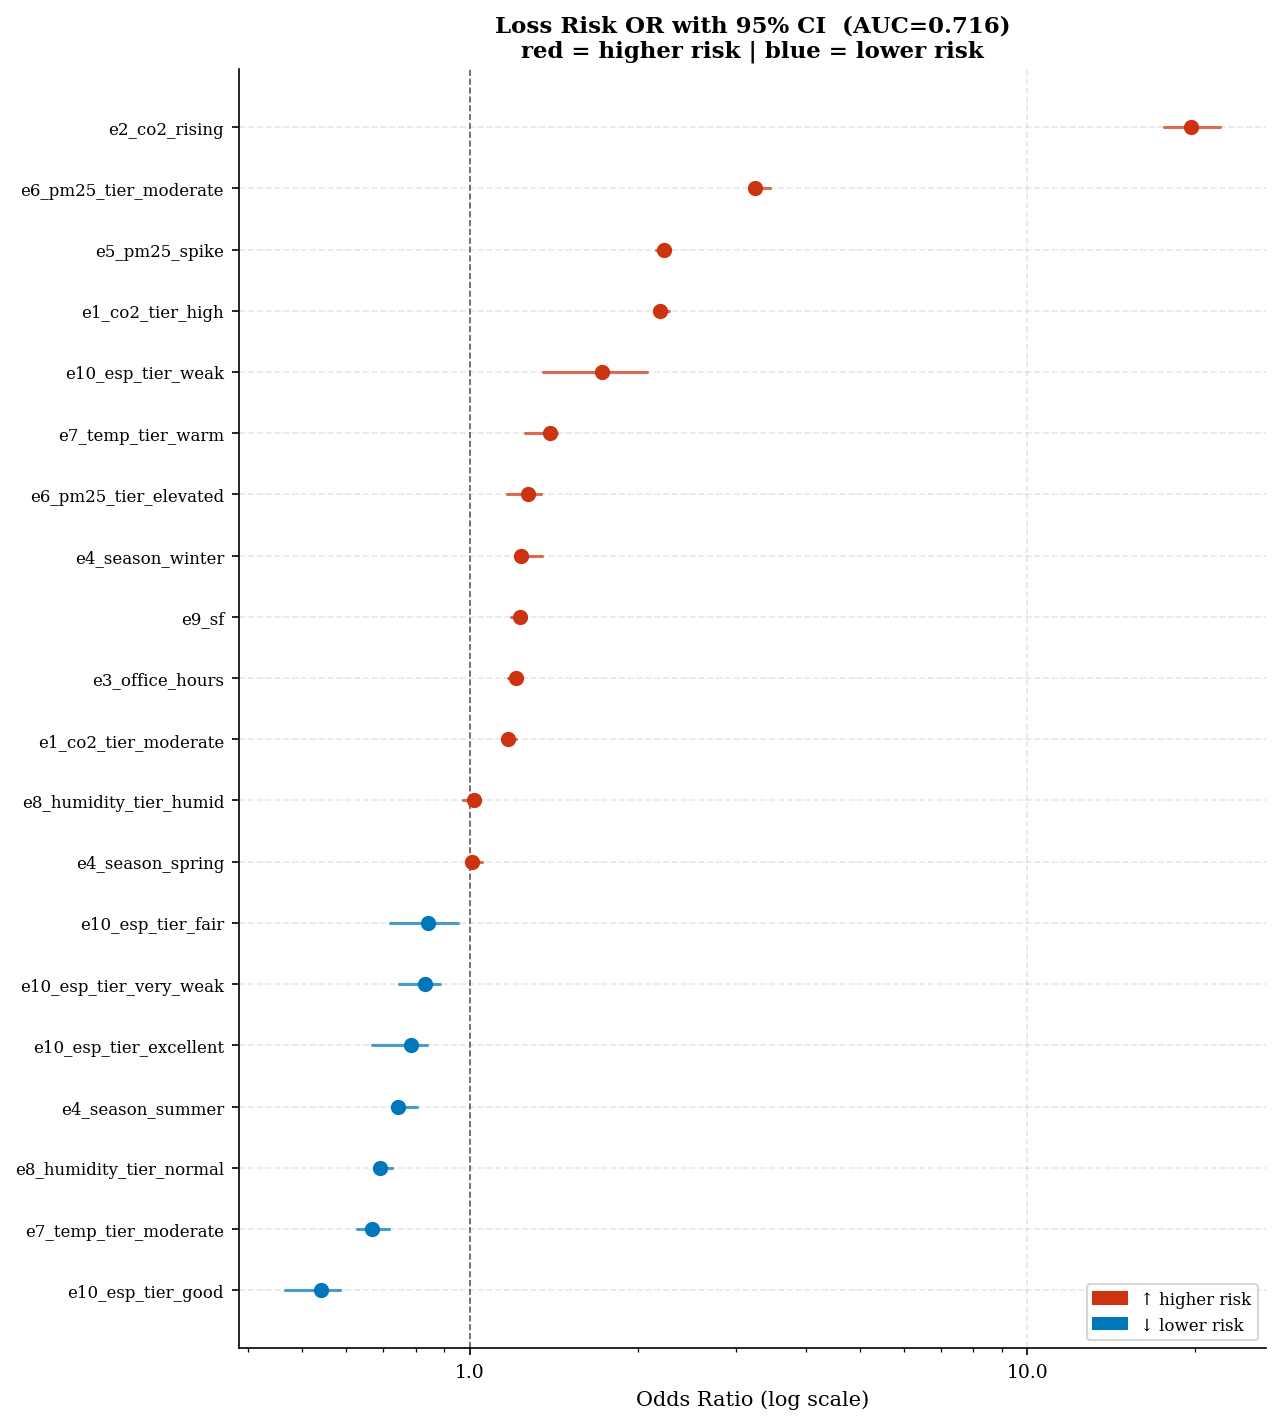

In [21]:
# Fig 03-J — Loss Risk Forest Plot (loss model only)
ev_loss_only = []
for feat in feat_names:
    if feat.startswith('device_id'): continue
    ev_loss_only.append({
        'predictor': feat,
        'OR_loss': float(odds_ratios.get(feat, 1.0)),
        'CI_lo': float(ci_loss.loc[feat, 'CI_lo']) if feat in ci_loss.index else 1.0,
        'CI_hi': float(ci_loss.loc[feat, 'CI_hi']) if feat in ci_loss.index else 1.0,
    })

ev_j = pd.DataFrame(ev_loss_only).sort_values('OR_loss', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(ev_j) * 0.38 + 2))

for i, row in ev_j.iterrows():
    color = C['red'] if row['OR_loss'] > 1 else C['blue']
    ax.plot([row['CI_lo'], row['CI_hi']], [i, i],
            color=color, lw=1.5, alpha=0.7, solid_capstyle='round')
    ax.scatter(row['OR_loss'], i, color=color, s=40, zorder=5)

ax.axvline(x=1.0, color='black', lw=0.8, ls='--', alpha=0.6)
ax.set_yticks(range(len(ev_j)))
ax.set_yticklabels(ev_j['predictor'], fontsize=8)
ax.set_xlabel('Odds Ratio (log scale)')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_title(f'Loss Risk OR with 95% CI  (AUC={auc_loss:.3f})\n'
             'red = higher risk | blue = lower risk', fontsize=11, fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=C['red'], label='\u2191 higher risk'),
                   mpatches.Patch(color=C['blue'], label='\u2193 lower risk')],
          loc='lower right', fontsize=8)

fig.tight_layout()
fig.subplots_adjust(left=0.30)
save_fig(fig, '03_j_loss_risk_forest')


## 11 · Burst Loss Risk Model  *(§7.7 — RQ3)*

Same framework predicting burst loss: `y = 1[tx_loss >= 3]`

Burst-loss ORs are systematically larger than packet-loss ORs for the same
events — high-occupancy and high-SF conditions disproportionately increase burst severity.


In [22]:
print('=' * 60)
print('LOGISTIC REGRESSION — BURST RISK MODEL (§7.7)')
print('=' * 60)

df_link['burst_occurred'] = (df_link['tx_loss'] >= 3).astype(int)
y_burst = df_link['burst_occurred'].values

print(f'Fitting burst risk model ({N_BOOT} bootstrap samples) ...')
or_burst, ci_burst, auc_burst = fit_lr_bootstrap(X, y_burst)
print(f'  AUC (burst risk) = {auc_burst:.3f}')

print(f'\n{"Predictor":<40} {"OR_loss":>10} {"OR_burst":>10} {"Ratio":>8}')
print('-' * 72)
print('--- EVENT PREDICTORS ---')
for feat in odds_ratios.index:
    if feat.startswith('device_id'): continue
    or_l = odds_ratios[feat]
    or_b = or_burst[feat]
    ratio = or_b / or_l if or_l > 0 else 0
    marker = ' ←' if ratio > 1.5 else ''
    print(f'{feat:<40} {or_l:>10.4f} {or_b:>10.4f} {ratio:>7.2f}x{marker}')

print('\n--- DEVICE FIXED EFFECTS ---')
for feat in odds_ratios.index:
    if not feat.startswith('device_id'): continue
    or_l = odds_ratios[feat]
    or_b = or_burst[feat]
    ratio = or_b / or_l if or_l > 0 else 0
    print(f'{feat:<40} {or_l:>10.4f} {or_b:>10.4f} {ratio:>7.2f}x')

print('\nNote: ratio > 1.5x means the condition amplifies burst severity')
print('      beyond its effect on isolated packet loss')

LOGISTIC REGRESSION — BURST RISK MODEL (§7.7)
Fitting burst risk model (10 bootstrap samples) ...
  AUC (burst risk) = 0.745

Predictor                                   OR_loss   OR_burst    Ratio
------------------------------------------------------------------------
--- EVENT PREDICTORS ---
e2_co2_rising                               19.6154    51.1402    2.61x ←
e6_pm25_tier_moderate                        3.2486     8.1477    2.51x ←
e5_pm25_spike                                2.2324     1.9061    0.85x
e1_co2_tier_high                             2.1922     2.1172    0.97x
e10_esp_tier_weak                            1.7288     1.5812    0.91x
e7_temp_tier_warm                            1.3938     0.7976    0.57x
e6_pm25_tier_elevated                        1.2721     1.2333    0.97x
e4_season_winter                             1.2377     0.5938    0.48x
e9_sf                                        1.2277     0.9766    0.80x
e3_office_hours                              1.2098 

Computing micro-granular burst size odds ratios (Sizes 0–9)...
  Saved: figures/03_k_loss_vs_detailed_burst_or


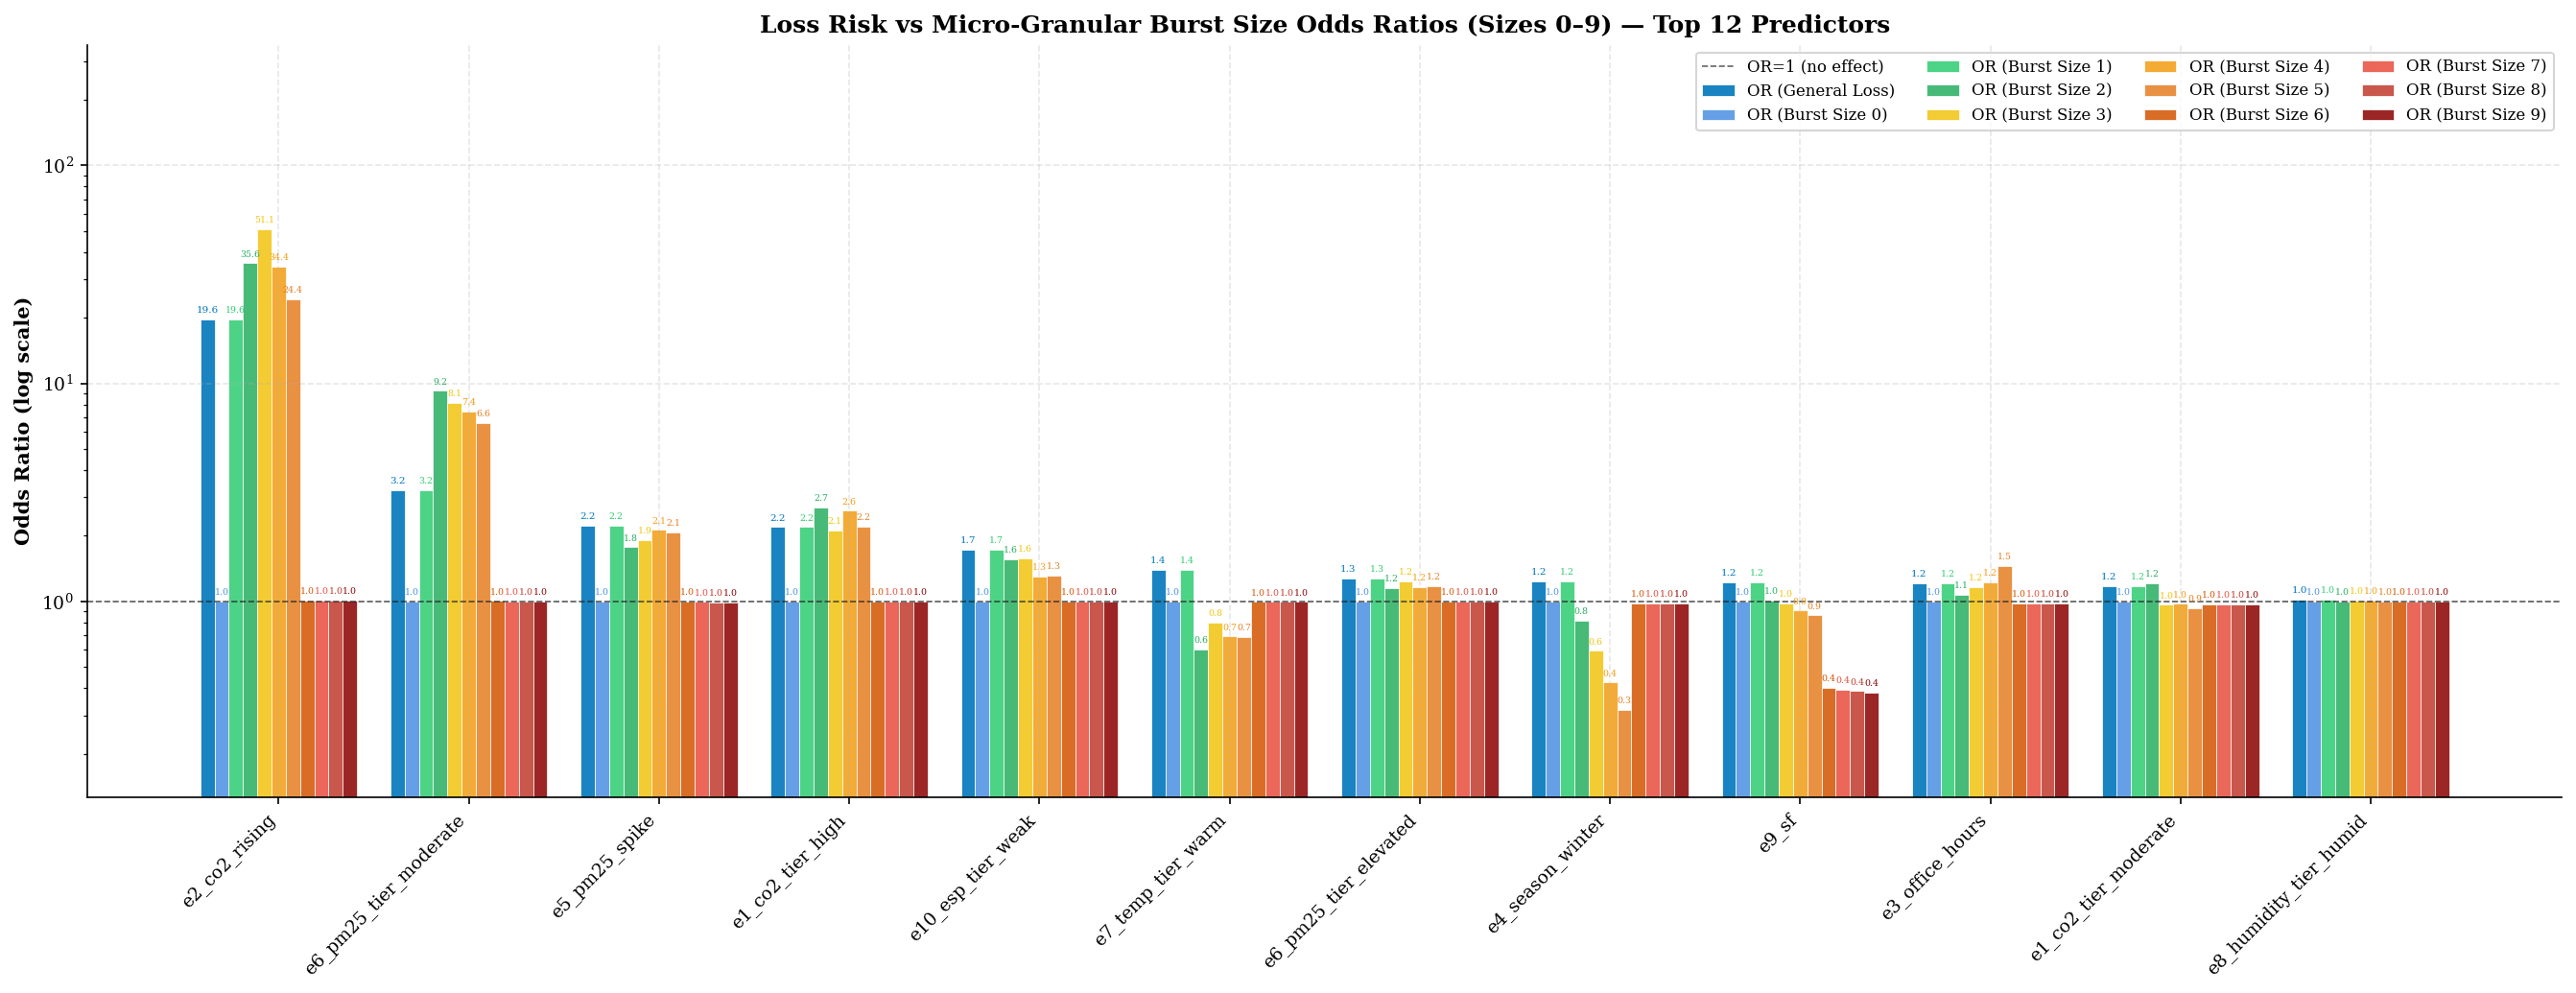

In [23]:
# Fig 03-K — Loss vs Detailed Burst Size OR comparison (top 12)
from sklearn.linear_model import LogisticRegression

print("Computing micro-granular burst size odds ratios (Sizes 0–9)...")
or_burst_sizes = {}
for size in range(10):
    if size == 0:
        # Size 0 represents perfect transmission / baseline reference condition
        or_burst_sizes[size] = {feat: 1.0 for feat in feat_names}
    else:
        # Fast single fit of logistic regression for cumulative burst severity: tx_loss >= size
        y_size = (df_link['tx_loss'] >= size).astype(int)
        if len(np.unique(y_size)) > 1:
            try:
                model = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0)
                model.fit(X, y_size)
                ors = np.exp(model.coef_[0])
                or_burst_sizes[size] = dict(zip(feat_names, ors))
            except Exception:
                or_burst_sizes[size] = {feat: 1.0 for feat in feat_names}
        else:
            or_burst_sizes[size] = {feat: 1.0 for feat in feat_names}

burst_sizes = list(range(10))  # 0 to 9 inclusive
ev_rows = []

for feat in feat_names:
    if feat.startswith('device_id'): continue

    row_dict = {
        'predictor': feat,
        'OR_loss': float(odds_ratios.get(feat, 1.0))
    }

    for size in burst_sizes:
        val = or_burst_sizes[size].get(feat, 1.0)
        row_dict[f'OR_burst_{size}'] = float(val)

    ev_rows.append(row_dict)

ev = pd.DataFrame(ev_rows)
ev_top = ev.sort_values('OR_loss', ascending=False).head(12).reset_index(drop=True)

x = np.arange(len(ev_top))
# 1 general loss bar + 10 individual burst size bars = 11 bars total per group
w = 0.075

fig, ax = plt.subplots(figsize=(18, 7))

# Plot General Loss baseline bar
ax.bar(x - 5 * w, ev_top['OR_loss'], w, color=C['blue'], alpha=0.9,
       label='OR (General Loss)', edgecolor='white', lw=0.4)

# 10 distinct colors matching your custom color environment context mapping from cool to hot
burst_colors = [
    '#4a90e2', '#2ecc71', '#27ae60', '#f1c40f', '#f39c12',
    '#e67e22', '#d35400', '#e74c3c', '#c0392b', '#8b0000'
]

for idx, size in enumerate(burst_sizes):
    ax.bar(x - (4 - idx) * w, ev_top[f'OR_burst_{size}'], w, color=burst_colors[idx],
           alpha=0.85, label=f'OR (Burst Size {size})', edgecolor='white', lw=0.4)

ax.axhline(y=1.0, color='black', lw=0.8, ls='--', alpha=0.6, label='OR=1 (no effect)')
ax.set_yscale('log')

# Micro-text layout for ultra-packed data columns
for i2, row in ev_top.iterrows():
    ax.text(i2 - 5 * w, row['OR_loss'] * 1.05, f'{row["OR_loss"]:.1f}', ha='center', va='bottom', fontsize=5, color=C['blue'])
    for idx, size in enumerate(burst_sizes):
        val = row[f'OR_burst_{size}']
        ax.text(i2 - (4 - idx) * w, val * 1.05, f'{val:.1f}', ha='center', va='bottom', fontsize=4.5, color=burst_colors[idx])

ax.set_xticks(x)
ax.set_xticklabels(ev_top['predictor'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Odds Ratio (log scale)', fontweight='bold')
ax.set_title('Loss Risk vs Micro-Granular Burst Size Odds Ratios (Sizes 0–9) — Top 12 Predictors', fontsize=12, fontweight='bold')

# Compact matrix legend layout to keep it clean
ax.legend(fontsize=8, loc='upper right', ncol=4)

all_or_cols = ['OR_loss'] + [f'OR_burst_{s}' for s in burst_sizes]
ax.set_ylim(bottom=min(ev_top[all_or_cols].min()) * 0.4, top=max(ev_top[all_or_cols].max()) * 7)

fig.tight_layout()
save_fig(fig, '03_k_loss_vs_detailed_burst_or')

## 12 · Key Findings Summary  *(§7 summary)*

Thesis-ready statements for Chapter 7.


In [24]:
print('=' * 65)
print('KEY FINDINGS SUMMARY')
print('=' * 65)

# PDR values needed for Key Findings summary
lost_link = int(df_link['tx_loss'].sum())
pdr_link = len(df_link) / (len(df_link) + lost_link) * 100
total_app = int(df['fw_drop'].sum())
total_radio = int(df['tx_loss'].sum())
pdr_system = len(df) / (len(df) + total_app + total_radio) * 100
pdr_raw = len(df) / (len(df) + total_radio) * 100

# Per-device PDR_link spread — near-uniform PDR is the headline
# evidence for the collision-dominated loss hypothesis
device_pdrs = df_link.groupby('device_id').apply(
    lambda g: len(g) / (len(g) + int(g['tx_loss'].sum())) * 100
)
pdr_range = float(device_pdrs.max() - device_pdrs.min())

print(f"""
┌─ RQ1: Campaign-Wide Reliability ───────────────────────┐
  PDR_system (full pipeline)  : {pdr_system:.2f}%
  PDR_raw    (radio layer)    : {pdr_raw:.2f}%
  PDR_link   (env. losses)    : {pdr_link:.2f}%
  PDR range across 6 devices  : {pdr_range:.2f} pp  ← collision-dominated evidence
  Total intervals analysed    : {len(df_link):,}
└─────────────────────────────────────────────────────────┘
""")

print(f"""
┌─ RQ2: Event-Conditioned PDR ───────────────────────┐
  Top findings ranked by effect size r:

  {'Event':<6} {'Comparison':<35} {'Diff(pp)':>9} {'r':>8}
  {'-' * 62}""")

for _, row in results_df.head(6).iterrows():
    print(f"  {row['Event']:<6} {row['Comparison']:<35} {row['Diff_pp']:>+8.2f} {row['Effect_r']:>8.4f}")

widening = joint_results['high']['gap'] - joint_results['background']['gap']
print(f"""
  SF × CO₂ interaction (§7.6 — novel finding):
    Background CO₂ : gap = {joint_results['background']['gap']:.2f} pp
    High CO₂       : gap = {joint_results['high']['gap']:.2f} pp
    Widening        : {widening:+.2f} pp → SF×occupancy interaction confirmed
└─────────────────────────────────────────────────────────┘
""")

print(f"""
┌─ RQ3: Strongest Predictors (Logistic Regression) ───────────┐
  AUC = {auc_loss:.3f} (loss risk)  |  AUC = {auc_burst:.3f} (burst risk)

  {'Predictor':<35} {'OR (loss)':>10} {'OR (burst)':>12}
  {'-' * 60}""")

top_predictors = [
    'e2_co2_rising', 'e1_co2_tier_high',
    'e6_pm25_tier_elevated', 'e5_pm25_spike',
    'e9_sf',
]
for feat in top_predictors:
    if feat not in odds_ratios.index:
        continue
    or_l = odds_ratios.get(feat, float('nan'))
    or_b = or_burst.get(feat, float('nan'))
    print(f"  {feat:<35} {or_l:>10.3f} {or_b:>12.3f}")

print(f"""
  Device fixed effects (relative to ED0):
    ED5 OR = {odds_ratios.get('device_id_ED5', float('nan')):.3f} — lower loss risk → supports collision hypothesis
└─────────────────────────────────────────────────────────┘
""")


KEY FINDINGS SUMMARY

┌─ RQ1: Campaign-Wide Reliability ───────────────────────┐
  PDR_system (full pipeline)  : 83.77%
  PDR_raw    (radio layer)    : 91.04%
  PDR_link   (env. losses)    : 92.10%
  PDR range across 6 devices  : 3.00 pp  ← collision-dominated evidence
  Total intervals analysed    : 2,634,828
└─────────────────────────────────────────────────────────┘


┌─ RQ2: Event-Conditioned PDR ───────────────────────┐
  Top findings ranked by effect size r:

  Event  Comparison                           Diff(pp)        r
  --------------------------------------------------------------
  E2     CO2 rising vs stable                  -83.25  -0.2531
  E6     Elevated vs Clean PM2.5               -17.18  -0.1190
  E1     High CO2 vs Background                 -2.05  -0.0241
  E5     PM2.5 spike vs normal                  +1.47  -0.0227
  E9     SF12 vs SF7                            -5.68  -0.0187
  E8     Humid vs Dry                           -1.07  -0.0133

  SF × CO₂ interaction

## 13 · Save Results


In [25]:
# save complete event results table
results_df.to_csv(DATA_DIR / '3_results.csv', index=False)

# save OR table — loss + burst + 95% CI (Table 7.8)
or_table = pd.DataFrame({
    'predictor': odds_ratios.index,
    'OR_loss': odds_ratios.values,
    'loss_CI_lo': [ci_loss.loc[f, 'CI_lo'] for f in odds_ratios.index],
    'loss_CI_hi': [ci_loss.loc[f, 'CI_hi'] for f in odds_ratios.index],
    'OR_burst': [or_burst[f] for f in odds_ratios.index],
    'burst_CI_lo': [ci_burst.loc[f, 'CI_lo'] for f in odds_ratios.index],
    'burst_CI_hi': [ci_burst.loc[f, 'CI_hi'] for f in odds_ratios.index],
})
or_table.to_csv(DATA_DIR / '3_odds_ratios.csv', index=False)

# save joint SF x CO2 interaction results (§7.6, novel finding)
joint_df = pd.DataFrame(joint_results).T
joint_df.index.name = 'co2_tier'
joint_df.to_csv(DATA_DIR / '3_joint_sf_co2.csv')

print(f'Saved: {DATA_DIR / "3_results.csv"}')
print(f'Saved: {DATA_DIR / "3_odds_ratios.csv"}')
print(f'Saved: {DATA_DIR / "3_joint_sf_co2.csv"}')
print(f'\nNotebook 03 complete.')


Saved: ..\data\3_results.csv
Saved: ..\data\3_odds_ratios.csv
Saved: ..\data\3_joint_sf_co2.csv

Notebook 03 complete.
